## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import missingno
import re

from sklearn.impute import KNNImputer
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr
import pickle

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../../Modules")
sys.path.insert(0, "../../../../Mamoth")

from utils import *
from Neural_Network_Module import give_predictions, Dataset


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\Python Virtual Environments\noa_eywa\Lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x0000018A3A3DA9D0> [0]

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Attica'
#NUTS2_EL = 'κεντρικης μακεδονιας'

In [4]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_NUTS3_2024_filled_mean_rain.csv', encoding=enc)
# wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Cases_NUTS3_2010-2023.csv', encoding=enc)

In [5]:
timeline_file.head()

,Unnamed: 0,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan
0,0,EL30,αττικη,EL307,"πειραιας, νησοι",22.925360,36.229230,2024-01-01,2024,1,0.333333,0.236287,-0.211370,-0.236287,0.293322,0.222155,-0.183893,-0.222155,0.042915,0.034998,0.039193,0.034998,14423.000000,14293.000000,3.054760,1,14304.331052,14087.548713,14394.326019,14104.761407,14497.570544,14130.389052,14839.469024,14344.606734,3.054760,3.054760,3.054760,3.054760
1,1,EL30,αττικη,EL307,"πειραιας, νησοι",22.925360,36.229230,2024-01-02,2024,1,0.333333,0.236287,-0.211370,-0.236287,0.293322,0.222155,-0.183893,-0.222155,0.042915,0.034998,0.039193,0.034998,14423.000000,14293.000000,0.941434,2,14304.331052,14087.548713,14394.326019,14104.761407,14497.570544,14130.389052,14839.469024,14344.606734,3.996194,3.996194,3.996194,3.996194
2,2,EL30,αττικη,EL307,"πειραιας, νησοι",22.925360,36.229230,2024-01-03,2024,1,0.333333,0.236287,-0.211370,-0.236287,0.293322,0.222155,-0.183893,-0.222155,0.042915,0.034998,0.039193,0.034998,14423.000000,14293.000000,0.504189,3,14304.331052,14087.548713,14394.326019,14104.761407,14497.570544,14130.389052,14839.469024,14344.606734,4.500383,4.500383,4.500383,4.500383
3,3,EL30,αττικη,EL307,"πειραιας, νησοι",22.925360,36.229230,2024-01-04,2024,1,0.333333,0.236287,-0.211370,-0.236287,0.293322,0.222155,-0.183893,-0.222155,0.042915,0.034998,0.039193,0.034998,14423.000000,14306.000000,2.075784,4,14304.331052,14087.548713,14394.326019,14104.761407,14497.570544,14130.389052,14839.469024,14344.606734,6.576167,6.576167,6.576167,6.576167
4,4,EL30,αττικη,EL307,"πειραιας, νησοι",22.925360,36.229230,2024-01-05,2024,1,0.455092,0.169199,-0.358748,-0.169199,0.392609,0.202817,-0.266726,-0.202817,0.065993,0.073509,0.117318,0.073509,14455.000000,14306.000000,0.334416,5,14304.331052,14087.548713,14394.326019,14104.761407,14497.570544,14130.389052,14839.469024,14344.606734,6.910583,6.910583,6.910583,6.910583


In [6]:
timeline_file.shape

(114192, 38)

In [7]:
# wnv_file.head()

In [8]:
# wnv_file.shape

In [9]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2
timeline_file['lst_jan_mean'] = (timeline_file['lst_day_jan_mean'] + timeline_file['lst_night_jan_mean'])/2
timeline_file['lst_feb_mean'] = (timeline_file['lst_day_feb_mean'] + timeline_file['lst_night_feb_mean'])/2
timeline_file['lst_mar_mean'] = (timeline_file['lst_day_mar_mean'] + timeline_file['lst_night_mar_mean'])/2
timeline_file['lst_apr_mean'] = (timeline_file['lst_day_apr_mean'] + timeline_file['lst_night_apr_mean'])/2

In [10]:
timeline_file['dt_placement'] = pd.to_datetime(timeline_file['dt_placement'])
timeline_file['day'] = timeline_file['dt_placement'].apply(lambda x : x.day)
timeline_file['month'] = timeline_file['dt_placement'].apply(lambda x : x.month)
timeline_file['year'] = timeline_file['dt_placement'].apply(lambda x : x.year)
timeline_file['week'] = timeline_file.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

timeline_file = encode_cyclical(timeline_file, 'day', 31)
timeline_file = encode_cyclical(timeline_file, 'month', 12)
timeline_file = encode_cyclical(timeline_file, 'week', 53)

In [11]:
timeline_file.rename(columns={"lst_day_jan_mean": "lst_jan_day_mean",
                        "lst_day_feb_mean": "lst_feb_day_mean",
                        "lst_day_mar_mean": "lst_mar_day_mean",
                        "lst_day_apr_mean": "lst_apr_day_mean",
                        "lst_night_jan_mean": "lst_jan_night_mean",
                        "lst_night_feb_mean": "lst_feb_night_mean",
                        "lst_night_mar_mean": "lst_mar_night_mean",
                        "lst_night_apr_mean": "lst_apr_night_mean"}, inplace=True)

### Add mosquito predictions from trained model

In [12]:
# dataset_list = []
# groups = timeline_file.groupby(['x', 'y', 'year'])

# for group, data in groups:
#     temp_df = data.copy()
#     temp_df.reset_index(drop=True, inplace=True)
#     temp_df['acc_rainfall_1week'] = temp_df['rainfall'].rolling(window=7, min_periods=0).sum()
#     temp_df['acc_rainfall_2week'] = temp_df['rainfall'].rolling(window=14, min_periods=0).sum()
#     temp_df['acc_rainfall_month'] = temp_df['rainfall'].rolling(window=30, min_periods=0).sum()
#     temp_df['acc_rainfall_jan'] = temp_df['dt_placement'].apply(lambda x: temp_df.loc[temp_df['dt_placement'] <= x, 'rainfall'].sum())
#     dataset_list.append(temp_df)

# dataset = pd.concat(dataset_list, ignore_index=True)
# dataset.reset_index(drop=True, inplace=True)

In [13]:
dataset = timeline_file.copy()

In [14]:
dataset.dtypes

Unnamed: 0                     int64
NUTS2_ID                      object
NUTS2_NAME                    object
NUTS3_ID                      object
NUTS3_NAME                    object
x                            float64
y                            float64
dt_placement          datetime64[ns]
year                           int64
month                          int64
ndvi                         float64
ndmi                         float64
ndwi                         float64
ndbi                         float64
ndvi_mean                    float64
ndmi_mean                    float64
ndwi_mean                    float64
ndbi_mean                    float64
ndvi_std                     float64
ndmi_std                     float64
ndwi_std                     float64
ndbi_std                     float64
lst_day                      float64
lst_night                    float64
rainfall                     float64
day                            int64
lst_jan_day_mean             float64
l

In [15]:
model = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_Culex_Mamoth_NN.pt', 'rb'))
imputer = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_Culex_KNN_Imputer.pkl', 'rb'))
scaler = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_Culex_Scaler.pkl', 'rb'))

In [16]:
mamoth_columns = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

In [17]:
dataset_mamoth = dataset_mamoth_preparation(dataset, mamoth_columns)

In [18]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [19]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<Axes: >

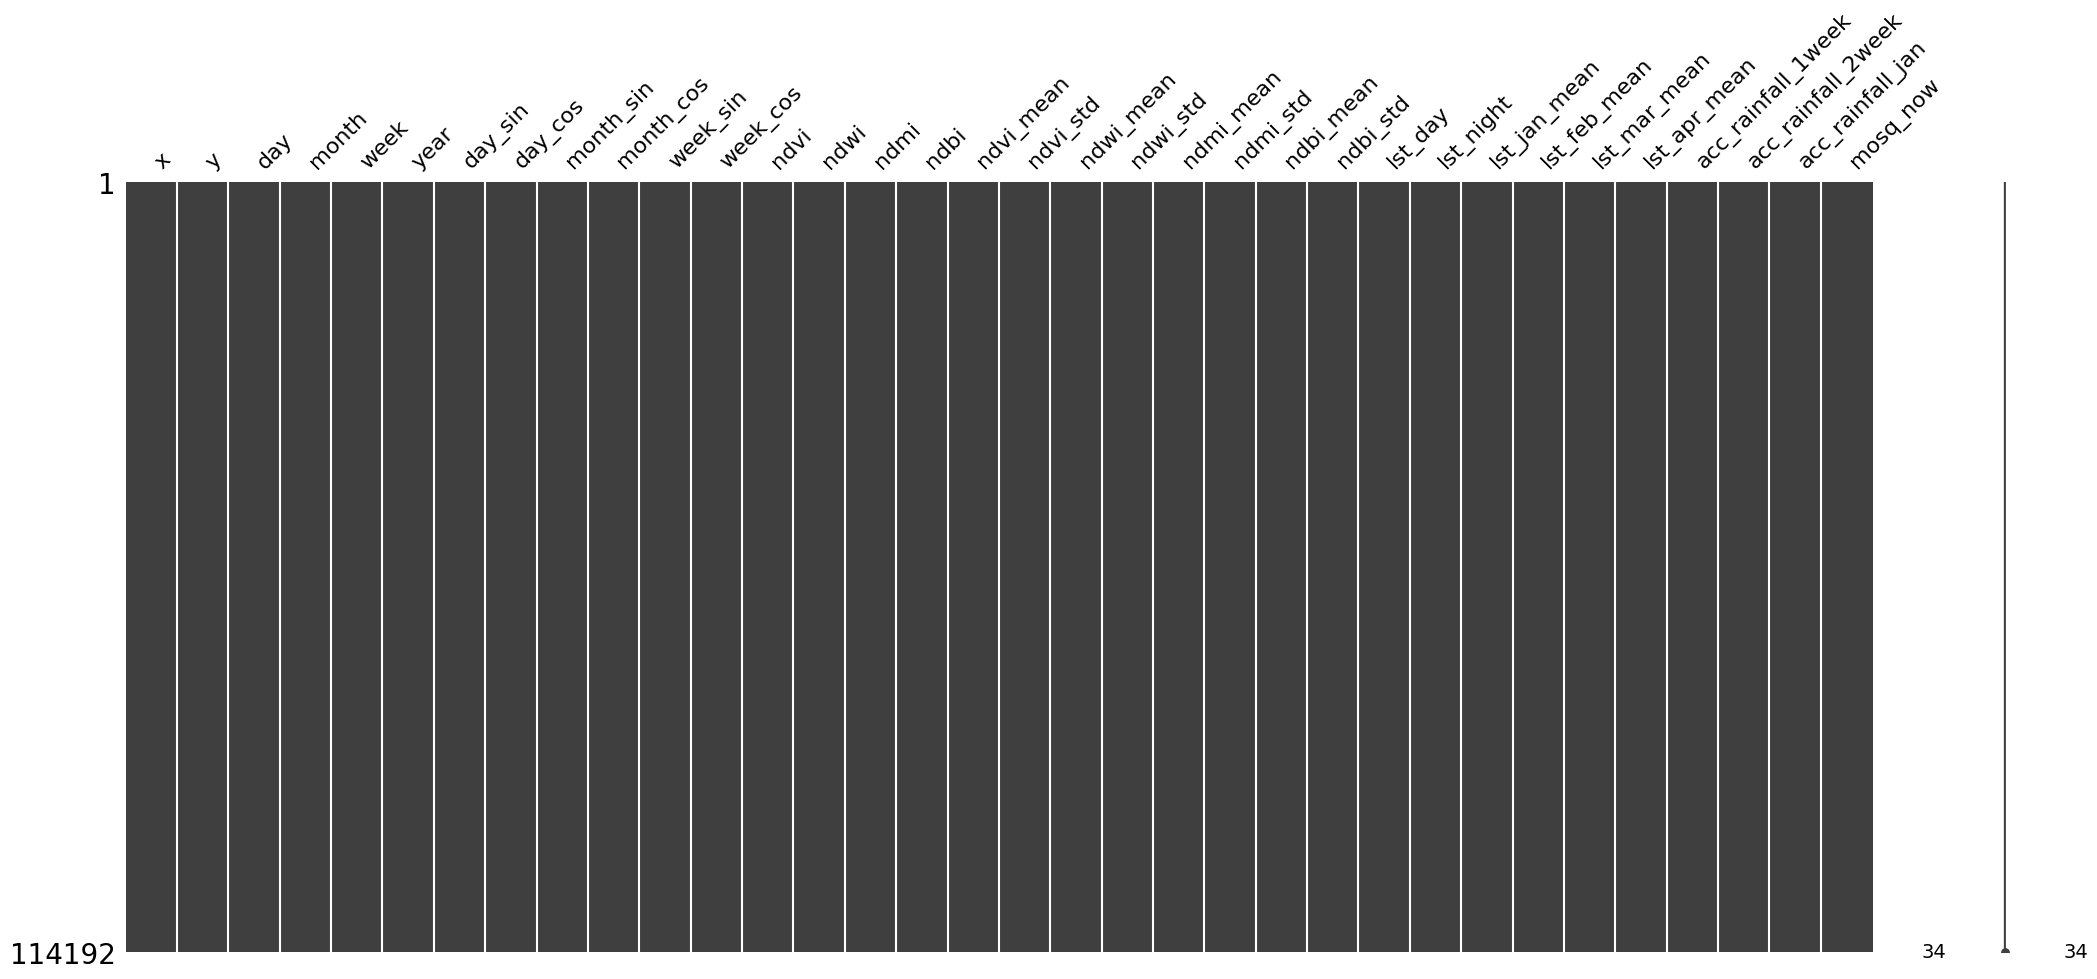

In [20]:
missingno.matrix(dataset_mamoth)

In [21]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [22]:
model_type = 'mosquito_regression'
transform_target = True

dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [23]:
predictions = give_predictions(model, dataset_mamoth)

In [24]:
mosqutio_predictions['mosq_pred'] = predictions
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,22.925360,36.229230,2024-01-01,1083
1,22.925360,36.229230,2024-01-02,1146
2,22.925360,36.229230,2024-01-03,1205
3,22.925360,36.229230,2024-01-04,1273
4,22.925360,36.229230,2024-01-05,1342
...,...,...,...,...
114187,24.052650,37.796350,2024-06-27,464
114188,24.052650,37.796350,2024-06-28,437
114189,24.052650,37.796350,2024-06-29,401
114190,24.052650,37.796350,2024-06-30,409


<Axes: >

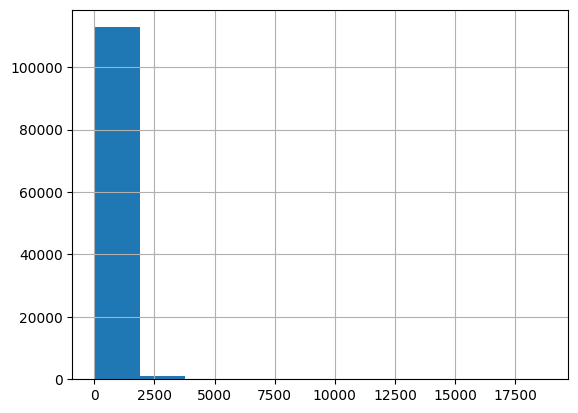

In [25]:
mosqutio_predictions.mosq_pred.hist()

In [26]:
mosqutio_predictions.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_Mosquito_Predictions_2024.csv", encoding = enc, index = False)

# mosqutio_predictions = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_Mosquito_Predictions_2009_2023.csv", encoding = enc)
# mosqutio_predictions['dt_placement'] = pd.to_datetime(mosqutio_predictions['dt_placement'])

#dataset = timeline_file

In [27]:
dataset = pd.merge(dataset, mosqutio_predictions,  how='left', on=['x', 'y', 'dt_placement'])

### Add Geomorphological and Land Cover/Use

In [28]:
dataset

,Unnamed: 0,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred
0,0,EL30,αττικη,EL307,"πειραιας, νησοι",22.925360,36.229230,2024-01-01,2024,1,0.333333,0.236287,-0.211370,-0.236287,0.293322,0.222155,-0.183893,-0.222155,0.042915,0.034998,0.039193,0.034998,14423.000000,14293.000000,3.054760,1,14304.331052,14087.548713,14394.326019,14104.761407,14497.570544,14130.389052,14839.469024,14344.606734,3.054760,3.054760,3.054760,3.054760,14358.000000,14195.939883,14249.543713,14313.979798,14592.037879,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,1083
1,1,EL30,αττικη,EL307,"πειραιας, νησοι",22.925360,36.229230,2024-01-02,2024,1,0.333333,0.236287,-0.211370,-0.236287,0.293322,0.222155,-0.183893,-0.222155,0.042915,0.034998,0.039193,0.034998,14423.000000,14293.000000,0.941434,2,14304.331052,14087.548713,14394.326019,14104.761407,14497.570544,14130.389052,14839.469024,14344.606734,3.996194,3.996194,3.996194,3.996194,14358.000000,14195.939883,14249.543713,14313.979798,14592.037879,1,0.394356,0.918958,0.500000,0.866025,0.118273,0.992981,1146
2,2,EL30,αττικη,EL307,"πειραιας, νησοι",22.925360,36.229230,2024-01-03,2024,1,0.333333,0.236287,-0.211370,-0.236287,0.293322,0.222155,-0.183893,-0.222155,0.042915,0.034998,0.039193,0.034998,14423.000000,14293.000000,0.504189,3,14304.331052,14087.548713,14394.326019,14104.761407,14497.570544,14130.389052,14839.469024,14344.606734,4.500383,4.500383,4.500383,4.500383,14358.000000,14195.939883,14249.543713,14313.979798,14592.037879,1,0.571268,0.820763,0.500000,0.866025,0.118273,0.992981,1205
3,3,EL30,αττικη,EL307,"πειραιας, νησοι",22.925360,36.229230,2024-01-04,2024,1,0.333333,0.236287,-0.211370,-0.236287,0.293322,0.222155,-0.183893,-0.222155,0.042915,0.034998,0.039193,0.034998,14423.000000,14306.000000,2.075784,4,14304.331052,14087.548713,14394.326019,14104.761407,14497.570544,14130.389052,14839.469024,14344.606734,6.576167,6.576167,6.576167,6.576167,14364.500000,14195.939883,14249.543713,14313.979798,14592.037879,1,0.724793,0.688967,0.500000,0.866025,0.118273,0.992981,1273
4,4,EL30,αττικη,EL307,"πειραιας, νησοι",22.925360,36.229230,2024-01-05,2024,1,0.455092,0.169199,-0.358748,-0.169199,0.392609,0.202817,-0.266726,-0.202817,0.065993,0.073509,0.117318,0.073509,14455.000000,14306.000000,0.334416,5,14304.331052,14087.548713,14394.326019,14104.761407,14497.570544,14130.389052,14839.469024,14344.606734,6.910583,6.910583,6.910583,6.910583,14380.500000,14195.939883,14249.543713,14313.979798,14592.037879,1,0.848644,0.528964,0.500000,0.866025,0.118273,0.992981,1342
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114187,114187,EL30,αττικη,EL305,ανατολικη αττικη,24.052650,37.796350,2024-06-27,2024,6,0.179128,-0.058272,-0.261784,0.058272,0.195413,-0.062499,-0.272704,0.062499,0.042326,0.027019,0.025970,0.027019,15393.000000,14727.000000,NaN,27,14274.944825,13972.505811,14392.648322,14015.165331,14548.789074,14042.785163,14949.948709,14295.846465,0.000000,0.000000,0.000000,469.335259,15060.000000,14123.725318,14203.906827,14295.787118,14622.897587,26,-0.724793,0.688967,0.000000,-1.000000,0.059241,-0.998244,464
114188,114188,EL30,αττικη,EL305,ανατολικη αττικη,24.052650,37.796350,2024-06-28,2024,6,0.169526,-0.077491,-0.256582,0.077491,0.184873,-0.080838,-0.266722,0.080838,0.039011,0.027418,0.022209,0.027418,15527.000000,14853.000000,NaN,28,14274.944825,13972.505811,14392.648322,140

In [29]:
dataset_locations = dataset[['x', 'y']].drop_duplicates(keep='first')
dataset_locations.reset_index(drop = True, inplace = True)

In [30]:
dataset_locations_per_year = dataset[['x', 'y', 'year']].drop_duplicates(keep='first')
dataset_locations_per_year.reset_index(drop = True, inplace = True)

In [31]:
dataset_locations

,x,y
0,22.925360,36.229230
1,22.925360,36.319060
2,22.925360,36.337030
3,22.947520,36.193290
4,22.947520,36.211260
...,...,...
619,24.029960,38.173650
620,24.029960,38.191620
621,24.052650,37.760420
622,24.052650,37.778380


In [32]:
dataset_locations_per_year

,x,y,year
0,22.925360,36.229230,2024
1,22.925360,36.319060,2024
2,22.925360,36.337030,2024
3,22.947520,36.193290,2024
4,22.947520,36.211260,2024
...,...,...,...
619,24.029960,38.173650,2024
620,24.029960,38.191620,2024
621,24.052650,37.760420,2024
622,24.052650,37.778380,2024


In [33]:
geomorphological = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Geomorphological.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [34]:
distances, indicies = calculate_nearest_topological(dataset_locations, geomorphological)
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.0
Max distance: 0.0


In [35]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

for index in indicies:
    df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

C:\Users\dimit\AppData\Local\Temp\ipykernel_4156\180837051.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)


In [36]:
dataset_geo = pd.concat([dataset_locations, df_geo], axis=1, join = 'outer')
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,22.925360,36.229230,1554.806149,2545.316809,27,217.502550,313.370600,207.335003,0.000000,1.499166
1,22.925360,36.319060,1765.480985,6926.111027,10,197.077479,274.126656,180.773992,0.000000,5.117532
2,22.925360,36.337030,1903.382813,7495.847864,15,235.283575,337.326003,186.903919,0.000000,1.487279
3,22.947520,36.193290,2106.538145,3337.921859,15,286.833435,337.525781,188.714498,0.000000,1.065822
4,22.947520,36.211260,2711.444137,4312.804250,4,126.015767,367.736329,184.865520,0.000000,1.847056
...,...,...,...,...,...,...,...,...,...,...
619,24.029960,38.173650,2600.269413,320.455355,2,168.777506,33.295211,185.121227,0.000000,20.137448
620,24.029960,38.191620,2409.735161,2308.570342,11,120.839265,92.644876,170.494784,0.000000,19.418511
621,24.052650,37.760420,1902.196929,317.090022,4,87.072386,92.438422,171.549039,0.000000,22.104813
622,24.052650,37.778380,2443.510197,317.013334,13,120.556372,93.715305,174.769053,0.000000,22.956556


In [37]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km         object
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [38]:
dataset_geo['slope_mean_1km'] = pd.to_numeric(dataset_geo['slope_mean_1km'], errors='coerce').astype('int64')

In [39]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km          int64
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [40]:
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,22.925360,36.229230,1554.806149,2545.316809,27,217.502550,313.370600,207.335003,0.000000,1.499166
1,22.925360,36.319060,1765.480985,6926.111027,10,197.077479,274.126656,180.773992,0.000000,5.117532
2,22.925360,36.337030,1903.382813,7495.847864,15,235.283575,337.326003,186.903919,0.000000,1.487279
3,22.947520,36.193290,2106.538145,3337.921859,15,286.833435,337.525781,188.714498,0.000000,1.065822
4,22.947520,36.211260,2711.444137,4312.804250,4,126.015767,367.736329,184.865520,0.000000,1.847056
...,...,...,...,...,...,...,...,...,...,...
619,24.029960,38.173650,2600.269413,320.455355,2,168.777506,33.295211,185.121227,0.000000,20.137448
620,24.029960,38.191620,2409.735161,2308.570342,11,120.839265,92.644876,170.494784,0.000000,19.418511
621,24.052650,37.760420,1902.196929,317.090022,4,87.072386,92.438422,171.549039,0.000000,22.104813
622,24.052650,37.778380,2443.510197,317.013334,13,120.556372,93.715305,174.769053,0.000000,22.956556


In [41]:
landcover = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Landcover_2001-2022.csv')
landcover.columns = landcover.columns.str.lower()

In [42]:
lc_columns = landcover.columns.tolist()
lc_columns = [x.split('_')[0] for x in lc_columns]

lc_columns
lc_years = set()

for i in range(0, len(lc_columns)):
    try:
        lc_years.add(int(lc_columns[i]))
    except ValueError:
        pass

lc_years = list(lc_years)

In [43]:
dates_ = re.compile(r"[0-9]{4}_[0-9]{2}_[0-9]{2}_")

for year in lc_years:
    frame_name = f'landcover_{year}'
    location_columns = ['x', 'y']
    filtered_columns = [col for col in landcover if col.startswith(f'{year}')]
    columns_to_keep = location_columns + filtered_columns
    locals()[frame_name] = landcover[columns_to_keep].copy()
    locals()[frame_name].insert(2, 'year', int(year))
    locals()[frame_name] = locals()[frame_name].rename(columns=lambda x: re.sub(dates_,'',x))

In [44]:
data_years = dataset_locations_per_year['year'].unique().tolist()

In [45]:
for year in data_years:
    frame_name = f'dataset_unique_points_annual_{year}'
    locals()[frame_name] = dataset_locations_per_year.query(f"year == {year}").copy()
    locals()[frame_name].reset_index(drop=True, inplace = True)

In [46]:
landcover_2024 = landcover_2023 = landcover_2022

In [47]:
for year in data_years:
    data_name = f'dataset_unique_points_annual_{year}'
    lc_name = f'landcover_{year}'
    merged_name = f'dataset_unique_points_annual_part{year}'
    distances, indicies = calculate_nearest_topological(locals()[data_name], locals()[lc_name])
    print(f'Year: {year}\nMin distance: {min(distances)}\nMax distance: {max(distances)}')

    df_lulc = pd.DataFrame()

    for index in indicies:
        df_lulc = pd.concat([df_lulc, locals()[lc_name].iloc[[index]]], ignore_index=True)

    df_lulc.drop(columns=['x', 'y', 'year'], inplace = True)
    df_lulc.reset_index(drop=True, inplace=True)

    locals()[merged_name] = pd.concat([locals()[data_name], df_lulc], axis=1, join = 'outer')

Year: 2024
Min distance: 0.0
Max distance: 0.0


In [48]:
dataset_lulc = pd.DataFrame()

for year in data_years:
    merged_name = f'dataset_unique_points_annual_part{year}'
    dataset_lulc = pd.concat([dataset_lulc, locals()[merged_name]], ignore_index=True)

In [49]:
dataset_lulc

,x,y,year,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,22.925360,36.229230,2024,22,85,20,85.000000,20,85,9,9,4,2,2,2,0
1,22.925360,36.319060,2024,21,76,20,76.000000,20,76,8,8,4,2,2,2,0
2,22.925360,36.337030,2024,11,85,10,81.000000,10,81,1,1,7,1,1,2,0
3,22.947520,36.193290,2024,22,86,20,86.000000,20,86,9,9,4,2,2,2,0
4,22.947520,36.211260,2024,31,91,30,91.000000,30,91,10,10,1,6,6,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
619,24.029960,38.173650,2024,31,99,36,96.000000,30,99,12,12,3,5,8,2,0
620,24.029960,38.191620,2024,31,89,30,89.000000,30,89,10,10,1,6,6,2,0
621,24.052650,37.760420,2024,31,95,30,95.000000,30,95,10,10,1,6,6,2,0
622,24.052650,37.778380,2024,31,97,30,97.000000,30,97,10,10,1,6,6,2,0


In [50]:
dataset_lulc.dtypes

x                      float64
y                      float64
year                     int64
lc_prop1                 int64
lc_prop1_assessment      int64
lc_prop2                 int64
lc_prop2_assessment    float64
lc_prop3                 int64
lc_prop3_assessment      int64
lc_type1                 int64
lc_type2                 int64
lc_type3                 int64
lc_type4                 int64
lc_type5                 int64
lw                       int64
qc                       int64
dtype: object

In [51]:
dataset = pd.merge(dataset, dataset_geo, on=['x', 'y'], how='left')

In [52]:
dataset = pd.merge(dataset, dataset_lulc, on=['x', 'y', 'year'], how='left')

In [53]:
dataset

,Unnamed: 0,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,0,EL30,αττικη,EL307,"πειραιας, νησοι",22.925360,36.229230,2024-01-01,2024,1,0.333333,0.236287,-0.211370,-0.236287,0.293322,0.222155,-0.183893,-0.222155,0.042915,0.034998,0.039193,0.034998,14423.000000,14293.000000,3.054760,1,14304.331052,14087.548713,14394.326019,14104.761407,14497.570544,14130.389052,14839.469024,14344.606734,3.054760,3.054760,3.054760,3.054760,14358.000000,14195.939883,14249.543713,14313.979798,14592.037879,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,1083,1554.806149,2545.316809,27,217.502550,313.370600,207.335003,0.000000,1.499166,22,85,20,85.000000,20,85,9,9,4,2,2,2,0
1,1,EL30,αττικη,EL307,"πειραιας, νησοι",22.925360,36.229230,2024-01-02,2024,1,0.333333,0.236287,-0.211370,-0.236287,0.293322,0.222155,-0.183893,-0.222155,0.042915,0.034998,0.039193,0.034998,14423.000000,14293.000000,0.941434,2,14304.331052,14087.548713,14394.326019,14104.761407,14497.570544,14130.389052,14839.469024,14344.606734,3.996194,3.996194,3.996194,3.996194,14358.000000,14195.939883,14249.543713,14313.979798,14592.037879,1,0.394356,0.918958,0.500000,0.866025,0.118273,0.992981,1146,1554.806149,2545.316809,27,217.502550,313.370600,207.335003,0.000000,1.499166,22,85,20,85.000000,20,85,9,9,4,2,2,2,0
2,2,EL30,αττικη,EL307,"πειραιας, νησοι",22.925360,36.229230,2024-01-03,2024,1,0.333333,0.236287,-0.211370,-0.236287,0.293322,0.222155,-0.183893,-0.222155,0.042915,0.034998,0.039193,0.034998,14423.000000,14293.000000,0.504189,3,14304.331052,14087.548713,14394.326019,14104.761407,14497.570544,14130.389052,14839.469024,14344.606734,4.500383,4.500383,4.500383,4.500383,14358.000000,14195.939883,14249.543713,14313.979798,14592.037879,1,0.571268,0.820763,0.500000,0.866025,0.118273,0.992981,1205,1554.806149,2545.316809,27,217.502550,313.370600,207.335003,0.000000,1.499166,22,85,20,85.000000,20,85,9,9,4,2,2,2,0
3,3,EL30,αττικη,EL307,"πειραιας, νησοι",22.925360,36.229230,2024-01-04,2024,1,0.333333,0.236287,-0.211370,-0.236287,0.293322,0.222155,-0.183893,-0.222155,0.042915,0.034998,0.039193,0.034998,14423.000000,14306.000000,2.075784,4,14304.331052,14087.548713,14394.326019,14104.761407,14497.570544,14130.389052,14839.469024,14344.606734,6.576167,6.576167,6.576167,6.576167,14364.500000,14195.939883,14249.543713,14313.979798,14592.037879,1,0.724793,0.688967,0.500000,0.866025,0.118273,0.992981,1273,1554.806149,2545.316809,27,217.502550,313.370600,207.335003,0.000000,1.499166,22,85,20,85.000000,20,85,9,9,4,2,2,2,0
4,4,EL30,αττικη,EL307,"πειραιας, νησοι",22.925360,36.229230,2024-01-05,2024,1,0.455092,0.169199,-0.358748,-0.169199,0.392609,0.202817,-0.266726,-0.202817,0.065993,0.073509,0.117318,0.073509,14455.000000,14306.000000,0.334416,5,14304.331052,14087.548713,14394.326019,14104.761407,14497.570544,14130.389052,14839.469024,14344.606734,6.910583,6.910583,6.910583,6.910583,14380.500000,14195.939883,14249.543713,14313.979798,14592.037879,1,0.848644,0.528964,0.500000,0.866025,0.118273,0.992981,1342,1554.806149,2545.316809,27,217.502550,313.370600,207.335003,0.000000,1.499166,22,85,20,85.000000,20,85,9,9,4,2,2,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

In [54]:
grouped_by_nuts3 = dataset.groupby(['dt_placement', 'NUTS2_ID',	'NUTS2_NAME','NUTS3_ID','NUTS3_NAME'], as_index = False)

In [55]:
grouped_by_nuts3_mods = grouped_by_nuts3.agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None).reset_index()

In [56]:
grouped_by_nuts3_mean = grouped_by_nuts3.mean()
grouped_by_nuts3_min = grouped_by_nuts3.min()
grouped_by_nuts3_max = grouped_by_nuts3.max()
grouped_by_nuts3_std = grouped_by_nuts3.std()

In [57]:
grouped_by_nuts3_min.rename(columns={'distance_to_coast': 'distance_to_coast_min', 'distance_to_river': 'distance_to_river_min', 
                                     'slope_mean_1km': 'slope_mean_1km_min', 'aspect_mean_200m': 'aspect_mean_200m_min', 
                                     'elevation_mean_1km': 'elevation_mean_1km_min', 'hillshade_mean_1km': 'hillshade_mean_1km_min',
                                     'fs_area_1km': 'fs_area_1km_min', 'flow_accu_200m': 'flow_accu_200m_min'}, inplace=True)

grouped_by_nuts3_max.rename(columns={'distance_to_coast': 'distance_to_coast_max', 'distance_to_river': 'distance_to_river_max', 
                                     'slope_mean_1km': 'slope_mean_1km_max', 'aspect_mean_200m': 'aspect_mean_200m_max', 
                                     'elevation_mean_1km': 'elevation_mean_1km_max', 'hillshade_mean_1km': 'hillshade_mean_1km_max',
                                     'fs_area_1km': 'fs_area_1km_max', 'flow_accu_200m': 'flow_accu_200m_max'}, inplace=True)

grouped_by_nuts3_std.rename(columns={'distance_to_coast': 'distance_to_coast_std', 'distance_to_river': 'distance_to_river_std', 
                                     'slope_mean_1km': 'slope_mean_1km_std', 'aspect_mean_200m': 'aspect_mean_200m_std', 
                                     'elevation_mean_1km': 'elevation_mean_1km_std', 'hillshade_mean_1km': 'hillshade_mean_1km_std',
                                     'fs_area_1km': 'fs_area_1km_std', 'flow_accu_200m': 'flow_accu_200m_std'}, inplace=True)

In [58]:
grouped_by_nuts3_mods.drop(columns=['index'], inplace = True)

In [59]:
grouped_by_nuts3_mods

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,Unnamed: 0,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,2024-01-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,64965,23.800770,38.054770,2024,1,0.095836,0.033150,-0.376321,-0.187220,0.109467,0.056017,-0.328542,-0.164907,0.020735,0.012509,0.011435,0.012509,14256.000000,14158.000000,4.085555,1,14249.174194,14009.615054,14415.857471,14061.908046,14569.477419,14110.477419,15000.188889,14390.033333,4.085555,4.085555,4.085555,4.085555,14160.000000,14129.394624,14238.882759,14339.977419,14695.111111,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,120,6975.099311,9.886334,3,158.038271,190.198124,179.915914,0.000000,1.000000,22,95,9,99.000000,20,95,13,13,10,8,9,2,0
1,2024-01-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,51240,23.681940,38.021300,2024,1,0.045267,-0.002357,-0.180006,-0.083864,0.076293,0.011507,-0.163493,-0.100638,0.021021,0.009280,0.017878,0.009280,14421.000000,14222.000000,2.194515,1,14353.251613,14046.696774,14487.324138,14132.682759,14615.909677,14200.838710,15085.960000,14473.800000,2.194515,2.194515,2.194515,2.194515,14314.500000,14199.974194,14310.003448,14408.374194,14779.880000,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,97,5369.544043,863.918625,1,124.980862,72.025314,168.746576,0.000000,2.741869,1,97,9,98.000000,1,97,13,13,10,8,9,2,0
2,2024-01-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,57828,23.743860,37.962720,2024,1,0.017763,-0.008618,-0.295697,-0.225806,0.064745,0.025713,-0.240630,-0.254104,0.036105,0.022282,0.030757,0.022282,14239.000000,14104.000000,2.447427,1,14289.258065,14044.903226,14422.803448,14114.793103,14587.280645,14177.438710,15019.970000,14440.700000,2.447427,2.447427,2.447427,2.447427,14171.500000,14167.080645,14268.798276,14382.359677,14730.335000,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,113,5491.611975,467.065216,3,162.183002,68.022695,183.011169,0.000000,1.000000,32,97,9,97.000000,30,97,13,13,10,8,9,2,0
3,2024-01-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,55815,23.729110,37.880760,2024,1,0.117574,0.030364,-0.236562,-0.113493,0.107070,0.055552,-0.209384,-0.113367,0.011887,0.011512,0.012272,0.011512,14366.000000,14192.000000,2.262071,1,14318.119816,14057.668203,14445.763547,14123.344828,14597.202765,14187.359447,14979.133333,14498.757143,2.262071,2.262071,2.262071,2.262071,14282.500000,14187.894009,14284.554187,14392.281106,14738.945238,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,112,1516.547200,306.529264,6,182.636564,28.747468,183.523543,0.000000,1.004064,32,97,9,99.000000,30,97,13,13,10,8,9,2,0
4,2024-01-01,EL30,αττικη,EL305,ανατολικη αττικη,52704,23.961890,38.155680,2024,1,-0.022890,-0.126609,-0.488043,-0.745717,-0.013396,-0.071624,-0.482105,-0.680449,0.000000,0.000000,0.000000,0.000000,14401.000000,14100.000000,2.588729,1,14274.944825,13972.505811,14392.648322,14015.165331,14548.789074,14042.785163,14949.948709,14295.846465,2.588729,2.588729,2.588729,2.588729,14234.500000,14123.725318,14203.906827,14295.787118,14622.897587,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,89,311.094326,25.720195,4,62.176422,3.555544,143.142636,0.000000,1.000000,31,97,30,94.000000,30,97,10,10,1,6,6,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [60]:
grouped_by_nuts3_min

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,Unnamed: 0,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,2024-01-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,64965,23.777980,38.018840,2024,1,0.095836,0.033150,-0.376321,-0.187220,0.109467,0.056017,-0.328542,-0.164907,0.020735,0.012509,0.011435,0.012509,14219.000000,14101.000000,2.825062,1,14249.174194,14009.615054,14415.857471,14061.908046,14569.477419,14110.477419,15000.188889,14390.033333,2.825062,2.825062,2.825062,2.825062,14160.000000,14129.394624,14238.882759,14339.977419,14695.111111,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,97,6975.099311,9.886334,2,158.038271,190.198124,179.915914,0.000000,1.000000,22,75,9,73.000000,20,75,10,10,1,6,6,2,0
1,2024-01-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,51240,23.659150,38.003330,2024,1,0.045267,-0.002357,-0.180006,-0.083864,0.076293,0.011507,-0.163493,-0.100638,0.021021,0.009280,0.017878,0.009280,14421.000000,14208.000000,2.194515,1,14353.251613,14046.696774,14487.324138,14132.682759,14615.909677,14200.838710,15085.960000,14473.800000,2.194515,2.194515,2.194515,2.194515,14314.500000,14199.974194,14310.003448,14408.374194,14779.880000,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,97,5369.544043,863.918625,1,124.980862,72.025314,168.746576,0.000000,2.741869,1,54,9,77.000000,1,54,13,13,10,8,9,2,0
2,2024-01-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,57828,23.721090,37.944760,2024,1,0.017763,-0.008618,-0.295697,-0.225806,0.064745,0.025713,-0.240630,-0.254104,0.036105,0.022282,0.030757,0.022282,14239.000000,14104.000000,2.447427,1,14289.258065,14044.903226,14422.803448,14114.793103,14587.280645,14177.438710,15019.970000,14440.700000,2.447427,2.447427,2.447427,2.447427,14171.500000,14167.080645,14268.798276,14382.359677,14730.335000,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,100,5491.611975,467.065216,3,162.183002,68.022695,183.011169,0.000000,1.000000,1,84,9,81.000000,1,84,9,9,4,1,1,2,0
3,2024-01-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,55815,23.706360,37.880760,2024,1,0.117574,0.030364,-0.236562,-0.113493,0.107070,0.055552,-0.209384,-0.113367,0.011887,0.011512,0.012272,0.011512,14366.000000,14192.000000,2.262071,1,14318.119816,14057.668203,14445.763547,14123.344828,14597.202765,14187.359447,14979.133333,14498.757143,2.262071,2.262071,2.262071,2.262071,14282.500000,14187.894009,14284.554187,14392.281106,14738.945238,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,112,1516.547200,306.529264,3,182.636564,28.747468,183.523543,0.000000,1.004064,1,61,9,80.000000,1,61,13,13,10,8,9,2,0
4,2024-01-01,EL30,αττικη,EL305,ανατολικη αττικη,52704,23.666920,37.670580,2024,1,-0.022890,-0.126609,-0.488043,-0.745717,-0.013396,-0.071624,-0.482105,-0.680449,0.000000,0.000000,0.000000,0.000000,14012.000000,13881.000000,0.822947,1,14274.944825,13972.505811,14392.648322,14015.165331,14548.789074,14042.785163,14949.948709,14295.846465,0.822947,0.822947,0.822947,0.822947,13997.500000,14123.725318,14203.906827,14295.787118,14622.897587,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,50,311.094326,25.720195,0,62.176422,3.555544,143.142636,0.000000,1.000000,11,67,9,67.000000,10,67,1,1,1,1,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [61]:
grouped_by_nuts3_dataset = pd.concat([grouped_by_nuts3_mods[['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME']], 
                                     grouped_by_nuts3_mean[['x','y']],
                                     grouped_by_nuts3_mods[['day','month','year','week']],
                                     grouped_by_nuts3_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std']],
                                     grouped_by_nuts3_mean[['lst_day','lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean','lst_night','lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean','lst','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']],
                                     grouped_by_nuts3_mean[['rainfall','acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan', 'mosq_pred']],
                                     grouped_by_nuts3_mean[['distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m']],
                                     grouped_by_nuts3_min[['distance_to_coast_min','distance_to_river_min','slope_mean_1km_min','aspect_mean_200m_min','elevation_mean_1km_min','hillshade_mean_1km_min','fs_area_1km_min','flow_accu_200m_min']],
                                     grouped_by_nuts3_max[['distance_to_coast_max','distance_to_river_max','slope_mean_1km_max','aspect_mean_200m_max','elevation_mean_1km_max','hillshade_mean_1km_max','fs_area_1km_max','flow_accu_200m_max']],
                                     grouped_by_nuts3_std[['distance_to_coast_std','distance_to_river_std','slope_mean_1km_std','aspect_mean_200m_std','elevation_mean_1km_std','hillshade_mean_1km_std','fs_area_1km_std','flow_accu_200m_std']],
                                     grouped_by_nuts3_mods[['lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw']]], axis=1)

In [62]:
grouped_by_nuts3_dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw
0,2024-01-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.825080,38.055971,1,1,2024,1,0.245841,0.105027,-0.219028,-0.105027,0.247997,0.116710,-0.212209,-0.116710,0.046434,0.037241,0.045205,0.037241,14340.266667,14249.174194,14415.857471,14569.477419,15000.188889,14148.200000,14009.615054,14061.908046,14110.477419,14390.033333,14244.233333,14129.394624,14238.882759,14339.977419,14695.111111,3.977890,3.977890,3.977890,3.977890,3.977890,116.933333,12596.173352,1653.260278,7.066667,199.653520,293.515429,186.164165,0.000000,11.320098,6975.099311,9.886334,2,158.038271,190.198124,179.915914,0.000000,1.000000,15103.584543,3887.958042,14,242.913089,460.563721,193.437501,0.000000,79.730978,2296.456415,1184.432609,4.682287,23.874457,92.528119,3.668097,0.000000,21.863192,22,9,20,13,13,10,8,9,2
1,2024-01-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.686502,38.024894,1,1,2024,1,0.093883,0.026622,-0.113095,-0.026622,0.118201,0.040443,-0.125937,-0.040443,0.057435,0.030250,0.039521,0.030250,14438.400000,14353.251613,14487.324138,14615.909677,15085.960000,14217.000000,14046.696774,14132.682759,14200.838710,14473.800000,14327.700000,14199.974194,14310.003448,14408.374194,14779.880000,2.809140,2.809140,2.809140,2.809140,2.809140,139.200000,7495.493496,2041.783345,2.800000,135.961772,107.413199,175.185410,0.000000,5.799639,5369.544043,863.918625,1,124.980862,72.025314,168.746576,0.000000,2.741869,9092.468792,3043.444411,5,157.020761,152.212002,180.041979,0.000000,9.259888,1549.348962,1081.112134,1.788854,12.696343,30.830096,4.405654,0.000000,2.978368,1,9,1,13,13,10,8,9,2
2,2024-01-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.757527,37.973503,1,1,2024,1,0.154682,0.085771,-0.120018,-0.085771,0.169194,0.099508,-0.130275,-0.099508,0.077158,0.047104,0.069463,0.047104,14394.300000,14289.258065,14422.803448,14587.280645,15019.970000,14217.900000,14044.903226,14114.793103,14177.438710,14440.700000,14306.100000,14167.080645,14268.798276,14382.359677,14730.335000,2.575792,2.575792,2.575792,2.575792,2.575792,134.300000,7451.460209,1907.131239,7.200000,218.497003,207.330391,190.939862,0.000000,2.773017,5491.611975,467.065216,3,162.183002,68.022695,183.011169,0.000000,1.000000,9901.346815,4576.388472,14,257.169814,553.363377,208.832872,0.000000,5.152035,1461.964111,1273.662642,4.211096,30.940738,139.781885,8.039500,0.000000,1.621831,32,9,30,13,13,10,8,9,2
3,2024-01-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.745366,37.906427,1,1,2024,1,0.170233,0.082196,-0.166970,-0.082196,0.169447,0.086035,-0.163352,-0.086035,0.056128,0.032010,0.046123,0.032010,14395.571429,14318.119816,14445.763547,14597.202765,14979.133333,14226.428571,14057.668203,14123.344828,14187.359447,14498.757143,14311.000000,14187.894009,14284.554187,14392.281106,14738.945238,2.341509,2.341509,2.341509,2.341509,2.341509,130.285714,2

<Axes: >

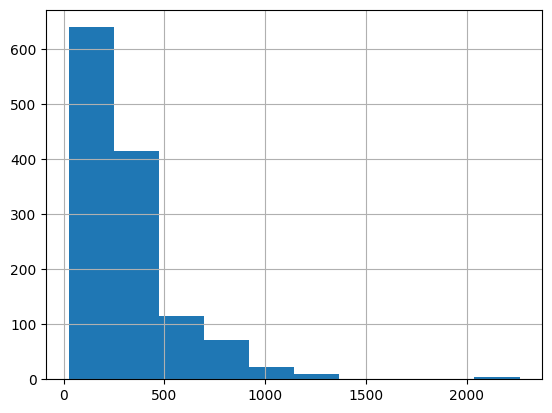

In [63]:
grouped_by_nuts3_dataset.mosq_pred.hist()

In [64]:
grouped_by_nuts3_dataset = convert_temperature(grouped_by_nuts3_dataset)

<Axes: >

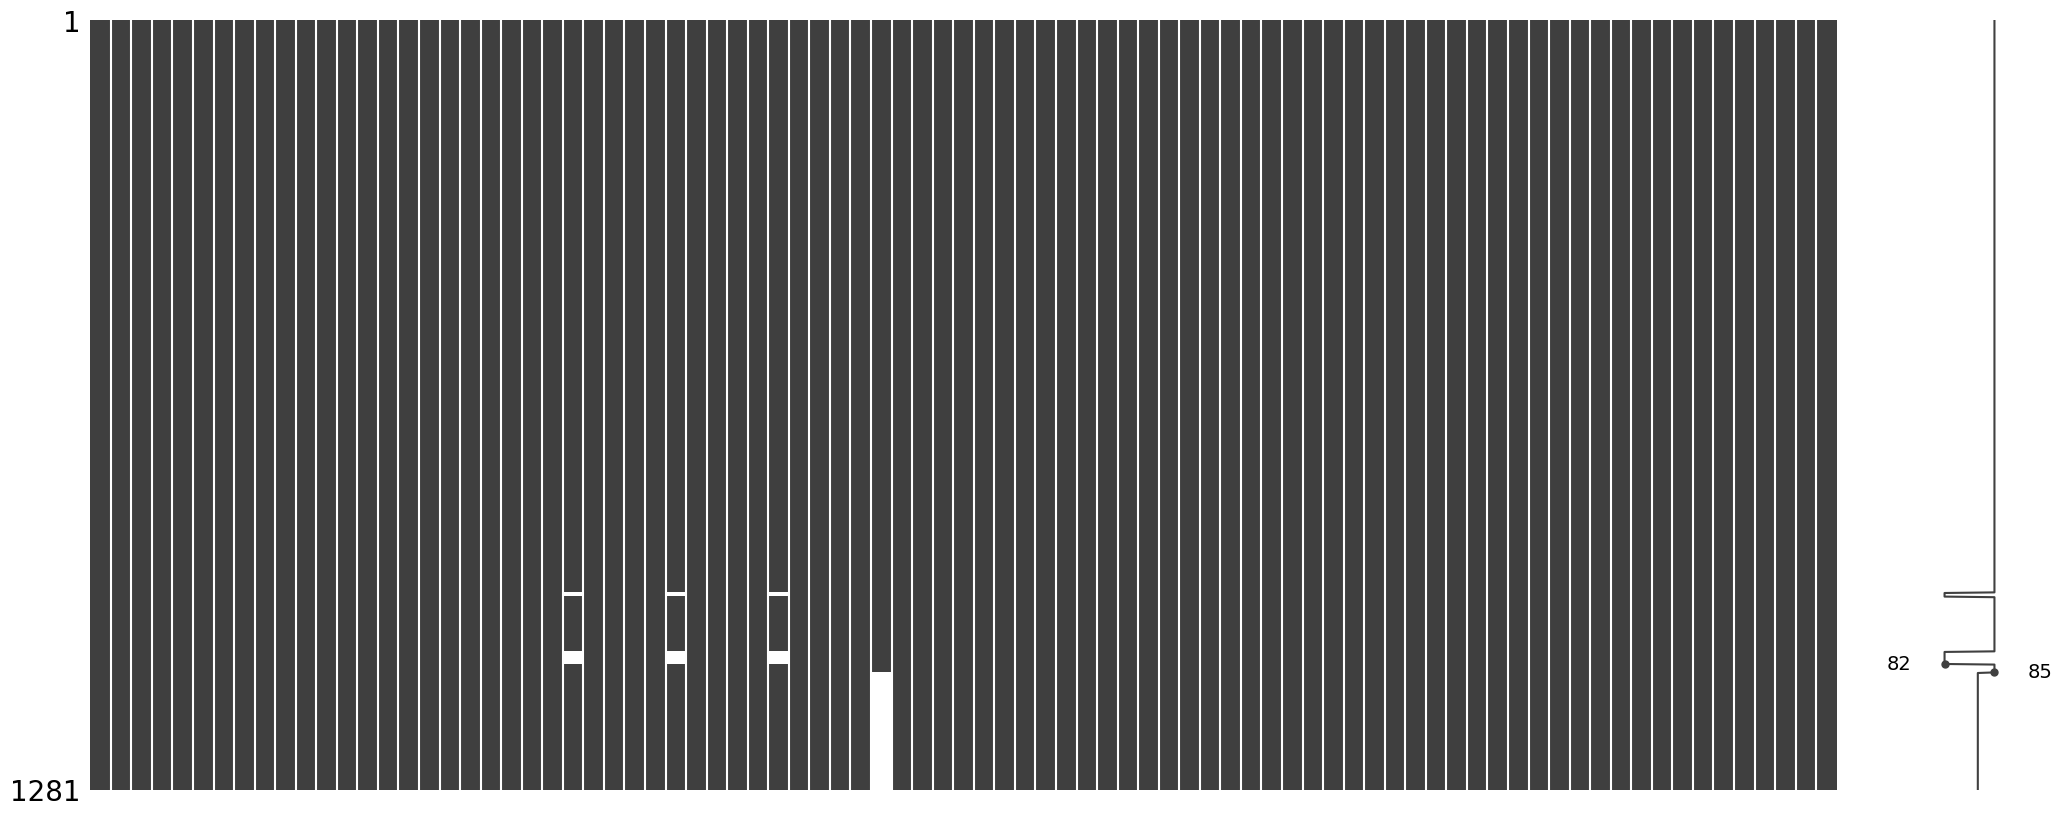

In [65]:
missingno.matrix(grouped_by_nuts3_dataset)

### Add Bio Variables ###

In [66]:
bio_values = []

for region in grouped_by_nuts3_dataset.NUTS3_NAME.unique():
    for year in grouped_by_nuts3_dataset.year.unique():
        for month in grouped_by_nuts3_dataset.month.unique():
            filtered_df = grouped_by_nuts3_dataset.loc[(grouped_by_nuts3_dataset['year'] == year) & (grouped_by_nuts3_dataset['NUTS3_NAME'] == region) & (grouped_by_nuts3_dataset['month'] == month)].copy()
            tmin = min(filtered_df['lst_day'].min(), filtered_df['lst_night'].min())
            tmax = max(filtered_df['lst_day'].max(), filtered_df['lst_night'].max())
            prec = filtered_df['rainfall'].sum()
            bio_values.append({'NUTS3_NAME': region, 
                               'year': year, 
                               'month': month, 
                               'monthly_lst_min': tmin, 
                               'monthly_lst_max': tmax,
                               'monthly_acc_prec': prec})

In [67]:
bio_values_df = pd.DataFrame(bio_values)

In [68]:
bio_values_df

,NUTS3_NAME,year,month,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,βορειος τομεας αθηνων,2024,1,2.624667,16.636667,121.319052
1,βορειος τομεας αθηνων,2024,2,2.243333,18.363333,128.793675
2,βορειος τομεας αθηνων,2024,3,5.452667,26.763333,171.778223
3,βορειος τομεας αθηνων,2024,4,6.898000,31.182000,62.423307
4,βορειος τομεας αθηνων,2024,5,12.658000,35.796667,129.387346
5,βορειος τομεας αθηνων,2024,6,20.930000,41.316667,0.000000
6,βορειος τομεας αθηνων,2024,7,26.467333,38.799333,0.000000
7,δυτικος τομεας αθηνων,2024,1,1.650000,17.514000,107.701138
8,δυτικος τομεας αθηνων,2024,2,2.790000,19.330000,150.727041
9,δυτικος τομεας αθηνων,2024,3,5.934000,27.594000,178.020111


In [69]:
dataset = pd.merge(grouped_by_nuts3_dataset, bio_values_df, on=['NUTS3_NAME', 'year', 'month'], how='left')

In [70]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2024-01-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.825080,38.055971,1,1,2024,1,0.245841,0.105027,-0.219028,-0.105027,0.247997,0.116710,-0.212209,-0.116710,0.046434,0.037241,0.045205,0.037241,13.655333,11.833484,15.167149,18.239548,26.853778,9.814000,7.042301,8.088161,9.059548,14.650667,11.734667,9.437892,11.627655,13.649548,20.752222,3.977890,3.977890,3.977890,3.977890,3.977890,116.933333,12596.173352,1653.260278,7.066667,199.653520,293.515429,186.164165,0.000000,11.320098,6975.099311,9.886334,2,158.038271,190.198124,179.915914,0.000000,1.000000,15103.584543,3887.958042,14,242.913089,460.563721,193.437501,0.000000,79.730978,2296.456415,1184.432609,4.682287,23.874457,92.528119,3.668097,0.000000,21.863192,22,9,20,13,13,10,8,9,2,2.624667,16.636667,121.319052
1,2024-01-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.686502,38.024894,1,1,2024,1,0.093883,0.026622,-0.113095,-0.026622,0.118201,0.040443,-0.125937,-0.040443,0.057435,0.030250,0.039521,0.030250,15.618000,13.915032,16.596483,19.168194,28.569200,11.190000,7.783935,9.503655,10.866774,16.326000,13.404000,10.849484,13.050069,15.017484,22.447600,2.809140,2.809140,2.809140,2.809140,2.809140,139.200000,7495.493496,2041.783345,2.800000,135.961772,107.413199,175.185410,0.000000,5.799639,5369.544043,863.918625,1,124.980862,72.025314,168.746576,0.000000,2.741869,9092.468792,3043.444411,5,157.020761,152.212002,180.041979,0.000000,9.259888,1549.348962,1081.112134,1.788854,12.696343,30.830096,4.405654,0.000000,2.978368,1,9,1,13,13,10,8,9,2,1.650000,17.514000,107.701138
2,2024-01-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.757527,37.973503,1,1,2024,1,0.154682,0.085771,-0.120018,-0.085771,0.169194,0.099508,-0.130275,-0.099508,0.077158,0.047104,0.069463,0.047104,14.736000,12.635161,15.306069,18.595613,27.249400,11.208000,7.748065,9.145862,10.398774,15.664000,12.972000,10.191613,12.225966,14.497194,21.456700,2.575792,2.575792,2.575792,2.575792,2.575792,134.300000,7451.460209,1907.131239,7.200000,218.497003,207.330391,190.939862,0.000000,2.773017,5491.611975,467.065216,3,162.183002,68.022695,183.011169,0.000000,1.000000,9901.346815,4576.388472,14,257.169814,553.363377,208.832872,0.000000,5.152035,1461.964111,1273.662642,4.211096,30.940738,139.781885,8.039500,0.000000,1.621831,32,9,30,13,13,10,8,9,2,2.068000,17.280000,97.468831
3,2024-01-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.745366,37.906427,1,1,2024,1,0.170233,0.082196,-0.166970,-0.082196,0.169447,0.086035,-0.163352,-0.086035,0.056128,0.032010,0.046123,0.032010,14.761429,13.212396,15.765271,18.794055,26.432667,11.378571,8.003364,9.316897,10.597189,16.825143,13.070000,10.607880,12.541084,14.695622,21.628905,2.341509,2.341509,2.341509,2.341509,2.341509,130.285714,2626.770961,1089.712354,6.285714,221.663863,97.544439,

<Axes: >

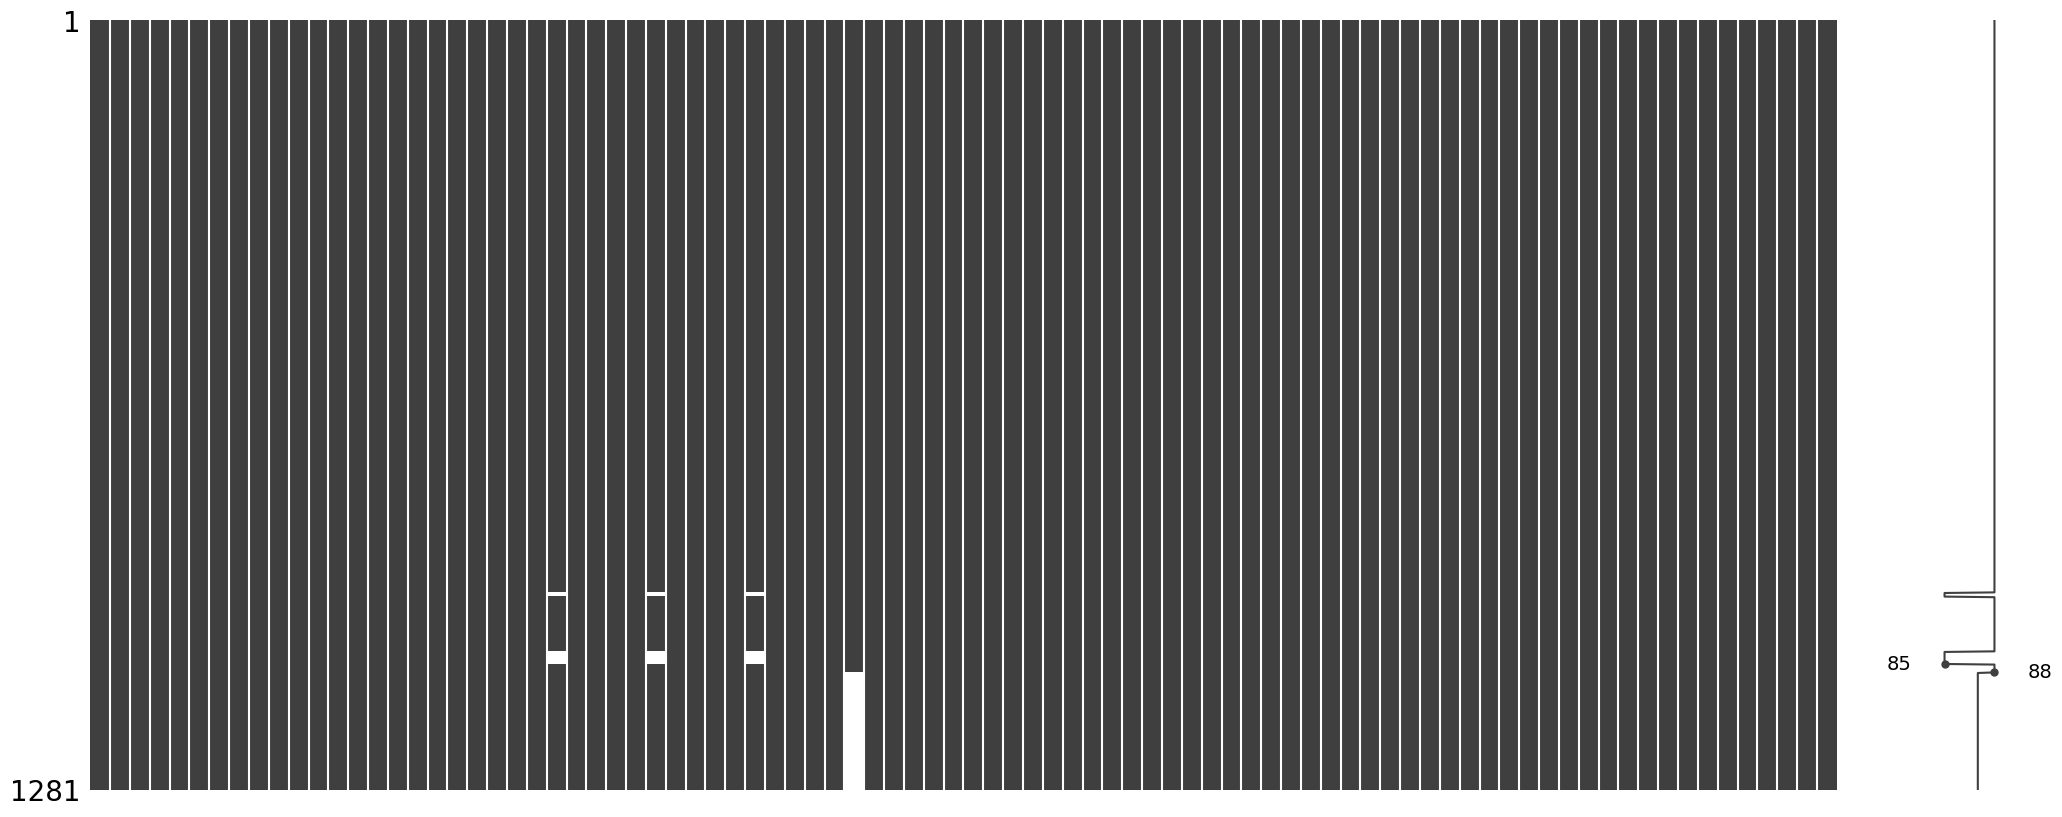

In [71]:
missingno.matrix(dataset)

In [72]:
dataset.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)

In [73]:
dataset['date_string'] = dataset['month'].astype(str) + '-' + dataset['year'].astype(str)
dataset['dt_placement'] = pd.to_datetime(dataset['date_string'], format='%m-%Y').dt.to_period('M')
dataset.drop(columns=['date_string'], inplace = True)

In [74]:
dataset

,dt_placement_daily,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,dt_placement
0,2024-01-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.825080,38.055971,1,1,2024,1,0.245841,0.105027,-0.219028,-0.105027,0.247997,0.116710,-0.212209,-0.116710,0.046434,0.037241,0.045205,0.037241,13.655333,11.833484,15.167149,18.239548,26.853778,9.814000,7.042301,8.088161,9.059548,14.650667,11.734667,9.437892,11.627655,13.649548,20.752222,3.977890,3.977890,3.977890,3.977890,3.977890,116.933333,12596.173352,1653.260278,7.066667,199.653520,293.515429,186.164165,0.000000,11.320098,6975.099311,9.886334,2,158.038271,190.198124,179.915914,0.000000,1.000000,15103.584543,3887.958042,14,242.913089,460.563721,193.437501,0.000000,79.730978,2296.456415,1184.432609,4.682287,23.874457,92.528119,3.668097,0.000000,21.863192,22,9,20,13,13,10,8,9,2,2.624667,16.636667,121.319052,2024-01
1,2024-01-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.686502,38.024894,1,1,2024,1,0.093883,0.026622,-0.113095,-0.026622,0.118201,0.040443,-0.125937,-0.040443,0.057435,0.030250,0.039521,0.030250,15.618000,13.915032,16.596483,19.168194,28.569200,11.190000,7.783935,9.503655,10.866774,16.326000,13.404000,10.849484,13.050069,15.017484,22.447600,2.809140,2.809140,2.809140,2.809140,2.809140,139.200000,7495.493496,2041.783345,2.800000,135.961772,107.413199,175.185410,0.000000,5.799639,5369.544043,863.918625,1,124.980862,72.025314,168.746576,0.000000,2.741869,9092.468792,3043.444411,5,157.020761,152.212002,180.041979,0.000000,9.259888,1549.348962,1081.112134,1.788854,12.696343,30.830096,4.405654,0.000000,2.978368,1,9,1,13,13,10,8,9,2,1.650000,17.514000,107.701138,2024-01
2,2024-01-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.757527,37.973503,1,1,2024,1,0.154682,0.085771,-0.120018,-0.085771,0.169194,0.099508,-0.130275,-0.099508,0.077158,0.047104,0.069463,0.047104,14.736000,12.635161,15.306069,18.595613,27.249400,11.208000,7.748065,9.145862,10.398774,15.664000,12.972000,10.191613,12.225966,14.497194,21.456700,2.575792,2.575792,2.575792,2.575792,2.575792,134.300000,7451.460209,1907.131239,7.200000,218.497003,207.330391,190.939862,0.000000,2.773017,5491.611975,467.065216,3,162.183002,68.022695,183.011169,0.000000,1.000000,9901.346815,4576.388472,14,257.169814,553.363377,208.832872,0.000000,5.152035,1461.964111,1273.662642,4.211096,30.940738,139.781885,8.039500,0.000000,1.621831,32,9,30,13,13,10,8,9,2,2.068000,17.280000,97.468831,2024-01
3,2024-01-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.745366,37.906427,1,1,2024,1,0.170233,0.082196,-0.166970,-0.082196,0.169447,0.086035,-0.163352,-0.086035,0.056128,0.032010,0.046123,0.032010,14.761429,13.212396,15.765271,18.794055,26.432667,11.378571,8.003364,9.316897,10.597189,16.825143,13.070000,10.607880,12.541084,14.695622,21.628905,2.341509,2.341509,2.341509,2.341509,2.341509,130.285714,2626.770961

In [75]:
grouped_by_month = dataset.drop(columns=['dt_placement_daily']).groupby(['dt_placement', 'NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME'], as_index = False)

grouped_by_month_mods = grouped_by_month.agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None).reset_index()
grouped_by_month_mean = grouped_by_month.mean()
grouped_by_month_min = grouped_by_month.min()
grouped_by_month_max = grouped_by_month.max()
grouped_by_month_sum = grouped_by_month.sum()
grouped_by_month_last = grouped_by_month.last()

grouped_by_month_mods

,index,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,0,2024-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.825080,38.055971,1,1,2024,1,0.251357,0.127626,-0.234683,-0.127626,0.245691,0.168850,-0.228610,-0.168850,0.038772,0.027193,0.029296,0.027193,11.454000,11.833484,15.167149,18.239548,26.853778,8.344667,7.042301,8.088161,9.059548,14.650667,8.754000,9.437892,11.627655,13.649548,20.752222,0.000000,1.246280,57.060006,91.634475,91.634475,180.933333,12596.173352,1653.260278,7.066667,199.653520,293.515429,186.164165,0.000000,11.320098,6975.099311,9.886334,2,158.038271,190.198124,179.915914,0.000000,1.000000,15103.584543,3887.958042,14,242.913089,460.563721,193.437501,0.000000,79.730978,2296.456415,1184.432609,4.682287,23.874457,92.528119,3.668097,0.000000,21.863192,22,9,20,13,13,10,8,9,2,2.624667,16.636667,121.319052
1,1,2024-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.686502,38.024894,1,1,2024,1,0.103583,0.021830,-0.128840,-0.021830,0.129217,0.035982,-0.142897,-0.035982,0.060471,0.030954,0.041788,0.030954,13.770000,13.915032,16.596483,19.168194,28.569200,10.350000,7.783935,9.503655,10.866774,16.326000,11.664000,10.849484,13.050069,15.017484,22.447600,0.000000,1.619005,4.324801,78.546110,78.546110,139.200000,7495.493496,2041.783345,2.800000,135.961772,107.413199,175.185410,0.000000,5.799639,5369.544043,863.918625,1,124.980862,72.025314,168.746576,0.000000,2.741869,9092.468792,3043.444411,5,157.020761,152.212002,180.041979,0.000000,9.259888,1549.348962,1081.112134,1.788854,12.696343,30.830096,4.405654,0.000000,2.978368,1,9,1,13,13,10,8,9,2,1.650000,17.514000,107.701138
2,2,2024-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.757527,37.973503,1,1,2024,1,0.168985,0.078481,-0.139090,-0.078481,0.185876,0.092917,-0.152091,-0.092917,0.082081,0.049596,0.073568,0.049596,12.580000,12.635161,15.306069,18.595613,27.249400,9.652000,7.748065,9.145862,10.398774,15.664000,11.116000,10.191613,12.225966,14.497194,21.456700,0.000000,1.286346,55.656226,78.591531,78.591531,134.300000,7451.460209,1907.131239,7.200000,218.497003,207.330391,190.939862,0.000000,2.773017,5491.611975,467.065216,3,162.183002,68.022695,183.011169,0.000000,1.000000,9901.346815,4576.388472,14,257.169814,553.363377,208.832872,0.000000,5.152035,1461.964111,1273.662642,4.211096,30.940738,139.781885,8.039500,0.000000,1.621831,32,9,30,13,13,10,8,9,2,2.068000,17.280000,97.468831
3,3,2024-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.745366,37.906427,1,1,2024,1,0.182967,0.075943,-0.185426,-0.075943,0.177720,0.079329,-0.177003,-0.079329,0.056748,0.031725,0.048218,0.031725,13.584286,13.212396,15.765271,18.794055,26.432667,1.890000,8.003364,9.316897,10.597189,16.825143,7.060000,10.607880,12.541084,14.695622,21.628905,0.000000,1.206818,57.579154,76.454022,76.454022,130.285714,2626.770961,1089.712354,6.285714,221.663863,9

In [76]:
grouped_by_month_dataset = pd.concat([grouped_by_month_mods[['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME', 'x', 'y', 'month', 'year']], 
                                     grouped_by_month_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std']],
                                     grouped_by_month_mean[['lst_day','lst_night','lst']].rename(columns={'lst_day': 'lst_day_mean', 'lst_night': 'lst_night_mean', 'lst': 'lst_mean'}),
                                     grouped_by_month_last[['lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean', 'lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']],
                                     grouped_by_month_mean[['rainfall']].rename(columns={'rainfall':'rainfall_mean'}),
                                     grouped_by_month_last[['acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan']],
                                     grouped_by_month_sum[['mosq_pred']].rename(columns={'mosq_pred':'mosq_pred_acc'}),
                                     grouped_by_month_mean[['mosq_pred']].rename(columns={'mosq_pred':'mosq_pred_mean'}),
                                     grouped_by_month_mods[['distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m']],
                                     grouped_by_month_mods[['distance_to_coast_min','distance_to_river_min','slope_mean_1km_min','aspect_mean_200m_min','elevation_mean_1km_min','hillshade_mean_1km_min','fs_area_1km_min','flow_accu_200m_min']],
                                     grouped_by_month_mods[['distance_to_coast_max','distance_to_river_max','slope_mean_1km_max','aspect_mean_200m_max','elevation_mean_1km_max','hillshade_mean_1km_max','fs_area_1km_max','flow_accu_200m_max']],
                                     grouped_by_month_mods[['distance_to_coast_std','distance_to_river_std','slope_mean_1km_std','aspect_mean_200m_std','elevation_mean_1km_std','hillshade_mean_1km_std','fs_area_1km_std','flow_accu_200m_std']],
                                     grouped_by_month_mods[['lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw']],
                                     grouped_by_month_mods[['monthly_lst_min','monthly_lst_max','monthly_acc_prec']]], axis=1)

In [77]:
grouped_by_month_dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2024-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.825080,38.055971,1,2024,0.249087,0.123696,-0.231308,-0.123696,0.246233,0.158698,-0.226363,-0.158698,0.039974,0.028491,0.031608,0.028491,11.833484,7.042301,9.437892,11.833484,15.167149,18.239548,26.853778,7.042301,8.088161,9.059548,14.650667,9.437892,11.627655,13.649548,20.752222,3.913518,29.682600,50.063076,117.341162,121.319052,5376.666667,173.440860,12596.173352,1653.260278,7.066667,199.653520,293.515429,186.164165,0.000000,11.320098,6975.099311,9.886334,2,158.038271,190.198124,179.915914,0.000000,1.000000,15103.584543,3887.958042,14,242.913089,460.563721,193.437501,0.000000,79.730978,2296.456415,1184.432609,4.682287,23.874457,92.528119,3.668097,0.000000,21.863192,22,9,20,13,13,10,8,9,2,2.624667,16.636667,121.319052
1,2024-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.686502,38.024894,1,2024,0.102331,0.022448,-0.126808,-0.022448,0.125197,0.047598,-0.137139,-0.047598,0.058575,0.030247,0.040470,0.030247,13.915032,7.783935,10.849484,13.915032,16.596483,19.168194,28.569200,7.783935,9.503655,10.866774,16.326000,10.849484,13.050069,15.017484,22.447600,3.474230,29.121529,46.517285,104.891998,107.701138,12014.400000,387.561290,7495.493496,2041.783345,2.800000,135.961772,107.413199,175.185410,0.000000,5.799639,5369.544043,863.918625,1,124.980862,72.025314,168.746576,0.000000,2.741869,9092.468792,3043.444411,5,157.020761,152.212002,180.041979,0.000000,9.259888,1549.348962,1081.112134,1.788854,12.696343,30.830096,4.405654,0.000000,2.978368,1,9,1,13,13,10,8,9,2,1.650000,17.514000,107.701138
2,2024-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.757527,37.973503,1,2024,0.167139,0.079421,-0.136629,-0.079421,0.183724,0.093767,-0.149276,-0.093767,0.081446,0.049275,0.073039,0.049275,12.635161,7.748065,10.191613,12.635161,15.306069,18.595613,27.249400,7.748065,9.145862,10.398774,15.664000,10.191613,12.225966,14.497194,21.456700,3.144156,18.877301,28.153147,94.893039,97.468831,10429.200000,336.425806,7451.460209,1907.131239,7.200000,218.497003,207.330391,190.939862,0.000000,2.773017,5491.611975,467.065216,3,162.183002,68.022695,183.011169,0.000000,1.000000,9901.346815,4576.388472,14,257.169814,553.363377,208.832872,0.000000,5.152035,1461.964111,1273.662642,4.211096,30.940738,139.781885,8.039500,0.000000,1.621831,32,9,30,13,13,10,8,9,2,2.068000,17.280000,97.468831
3,2024-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.745366,37.906427,1,2024,0.181324,0.076750,-0.183045,-0.076750,0.176652,0.080194,-0.175242,-0.080194,0.056668,0.031762,0.047948,0.031762,13.212396,8.003364,10.607880,13.212396,15.765271,18.794055,26.432667,8.003364,9.316897,10.597189,16.825143,10.607880,12.541084,14.695622,21.628905,2.939181,14.660600,21.391674,88.773113,91.114622,9531.0000

In [78]:
# wnv_file.head(5)

In [79]:
grouped_by_month_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 87 columns):
 #   Column                  Non-Null Count  Dtype    
---  ------                  --------------  -----    
 0   dt_placement            49 non-null     period[M]
 1   NUTS2_ID                49 non-null     object   
 2   NUTS2_NAME              49 non-null     object   
 3   NUTS3_ID                49 non-null     object   
 4   NUTS3_NAME              49 non-null     object   
 5   x                       49 non-null     float64  
 6   y                       49 non-null     float64  
 7   month                   49 non-null     int64    
 8   year                    49 non-null     int64    
 9   ndvi                    49 non-null     float64  
 10  ndmi                    49 non-null     float64  
 11  ndwi                    49 non-null     float64  
 12  ndbi                    49 non-null     float64  
 13  ndvi_mean               49 non-null     float64  
 14  ndmi_mean   

In [80]:
# wnv_file.info()

In [81]:
# wnv_file['dt_placement'] = pd.to_datetime(wnv_file['dt_placement'], format='%Y-%m').dt.to_period('M')

In [82]:
# wnv_file

In [83]:
# wnv_file['cases'].value_counts()

In [84]:
# wnv_file.cases.sum()

In [85]:
# merged = grouped_by_month_dataset.merge(wnv_file, how='left', on=['dt_placement', 'NUTS3_NAME', 'NUTS2_NAME'] )
merged = grouped_by_month_dataset.copy()

In [86]:
merged['cases'] = 0

In [87]:
merged

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases
0,2024-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.825080,38.055971,1,2024,0.249087,0.123696,-0.231308,-0.123696,0.246233,0.158698,-0.226363,-0.158698,0.039974,0.028491,0.031608,0.028491,11.833484,7.042301,9.437892,11.833484,15.167149,18.239548,26.853778,7.042301,8.088161,9.059548,14.650667,9.437892,11.627655,13.649548,20.752222,3.913518,29.682600,50.063076,117.341162,121.319052,5376.666667,173.440860,12596.173352,1653.260278,7.066667,199.653520,293.515429,186.164165,0.000000,11.320098,6975.099311,9.886334,2,158.038271,190.198124,179.915914,0.000000,1.000000,15103.584543,3887.958042,14,242.913089,460.563721,193.437501,0.000000,79.730978,2296.456415,1184.432609,4.682287,23.874457,92.528119,3.668097,0.000000,21.863192,22,9,20,13,13,10,8,9,2,2.624667,16.636667,121.319052,0
1,2024-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.686502,38.024894,1,2024,0.102331,0.022448,-0.126808,-0.022448,0.125197,0.047598,-0.137139,-0.047598,0.058575,0.030247,0.040470,0.030247,13.915032,7.783935,10.849484,13.915032,16.596483,19.168194,28.569200,7.783935,9.503655,10.866774,16.326000,10.849484,13.050069,15.017484,22.447600,3.474230,29.121529,46.517285,104.891998,107.701138,12014.400000,387.561290,7495.493496,2041.783345,2.800000,135.961772,107.413199,175.185410,0.000000,5.799639,5369.544043,863.918625,1,124.980862,72.025314,168.746576,0.000000,2.741869,9092.468792,3043.444411,5,157.020761,152.212002,180.041979,0.000000,9.259888,1549.348962,1081.112134,1.788854,12.696343,30.830096,4.405654,0.000000,2.978368,1,9,1,13,13,10,8,9,2,1.650000,17.514000,107.701138,0
2,2024-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.757527,37.973503,1,2024,0.167139,0.079421,-0.136629,-0.079421,0.183724,0.093767,-0.149276,-0.093767,0.081446,0.049275,0.073039,0.049275,12.635161,7.748065,10.191613,12.635161,15.306069,18.595613,27.249400,7.748065,9.145862,10.398774,15.664000,10.191613,12.225966,14.497194,21.456700,3.144156,18.877301,28.153147,94.893039,97.468831,10429.200000,336.425806,7451.460209,1907.131239,7.200000,218.497003,207.330391,190.939862,0.000000,2.773017,5491.611975,467.065216,3,162.183002,68.022695,183.011169,0.000000,1.000000,9901.346815,4576.388472,14,257.169814,553.363377,208.832872,0.000000,5.152035,1461.964111,1273.662642,4.211096,30.940738,139.781885,8.039500,0.000000,1.621831,32,9,30,13,13,10,8,9,2,2.068000,17.280000,97.468831,0
3,2024-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.745366,37.906427,1,2024,0.181324,0.076750,-0.183045,-0.076750,0.176652,0.080194,-0.175242,-0.080194,0.056668,0.031762,0.047948,0.031762,13.212396,8.003364,10.607880,13.212396,15.765271,18.794055,26.432667,8.003364,9.316897,10.597189,16.825143,10.607880,12.541084,14.695622,21.628905,2.939181,14.660600,21.391674,88.773113,91.1146

In [88]:
merged = fillna(merged,{'cases': 0})

In [89]:
merged['cases'].value_counts()

cases
0    49
Name: count, dtype: int64

In [90]:
merged.cases.sum()

0

In [91]:
merged = merged.astype({'cases': 'int'})

<Axes: >

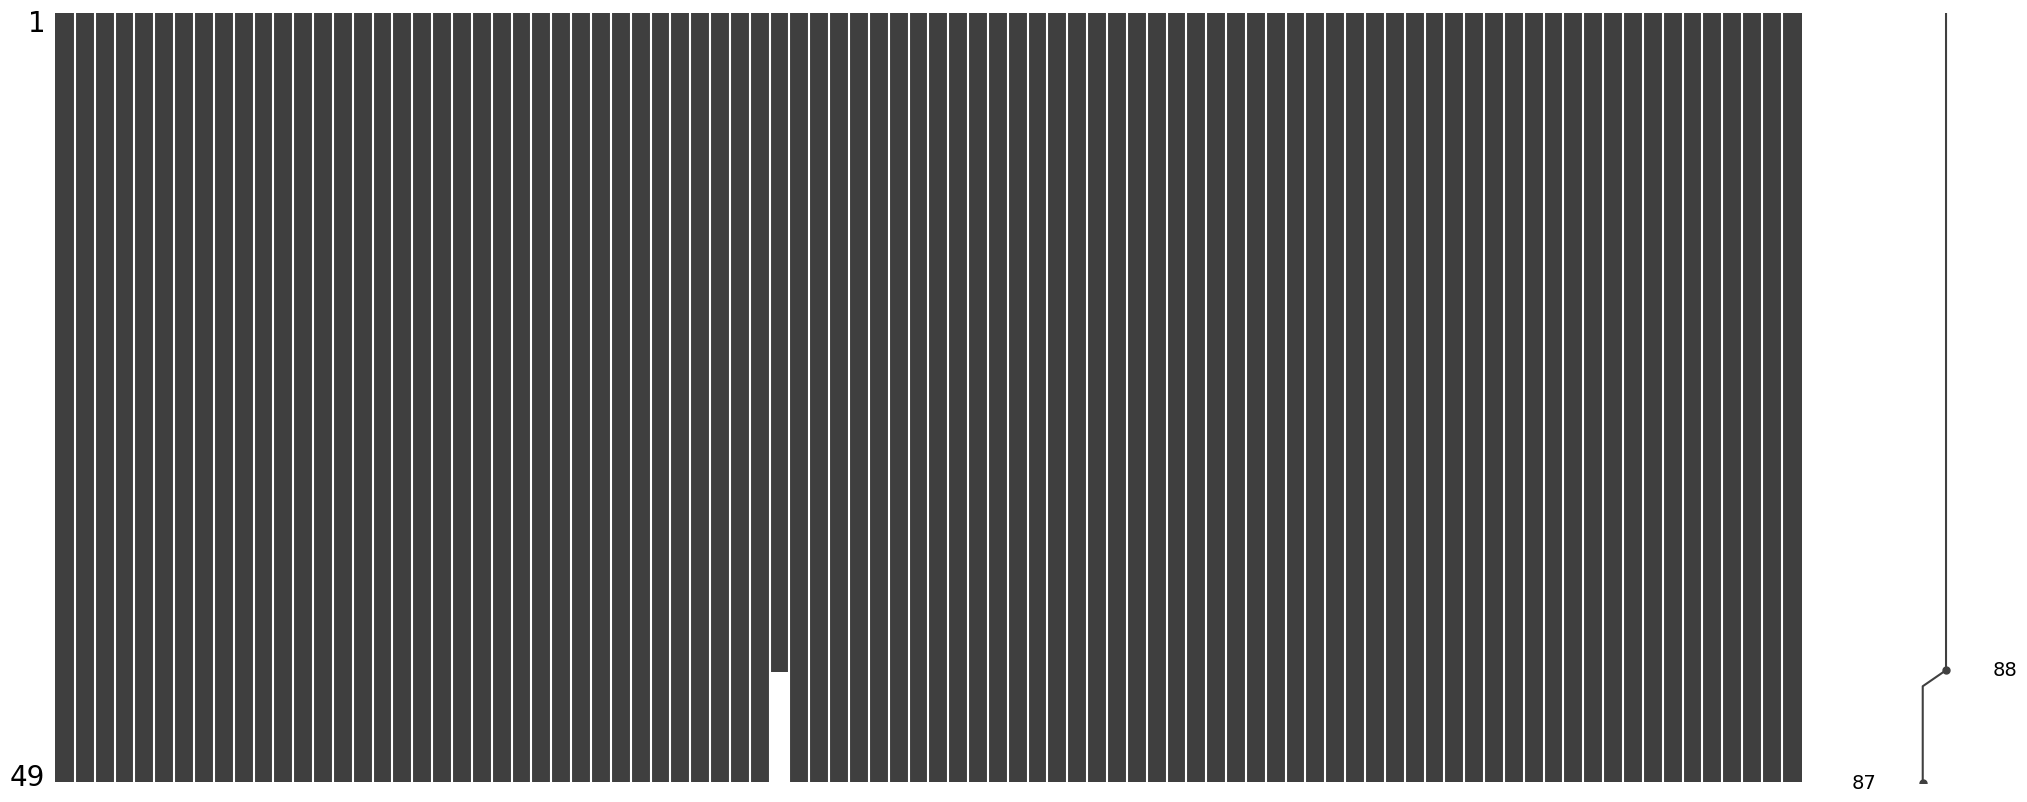

In [92]:
missingno.matrix(merged)

In [93]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'month', 'year', 'monthly_lst_min', 'monthly_lst_max']

temp_df = merged[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['monthly_lst_min', 'monthly_lst_max']

merged[imputed_columns] = imputed_data[imputed_columns]

<Axes: >

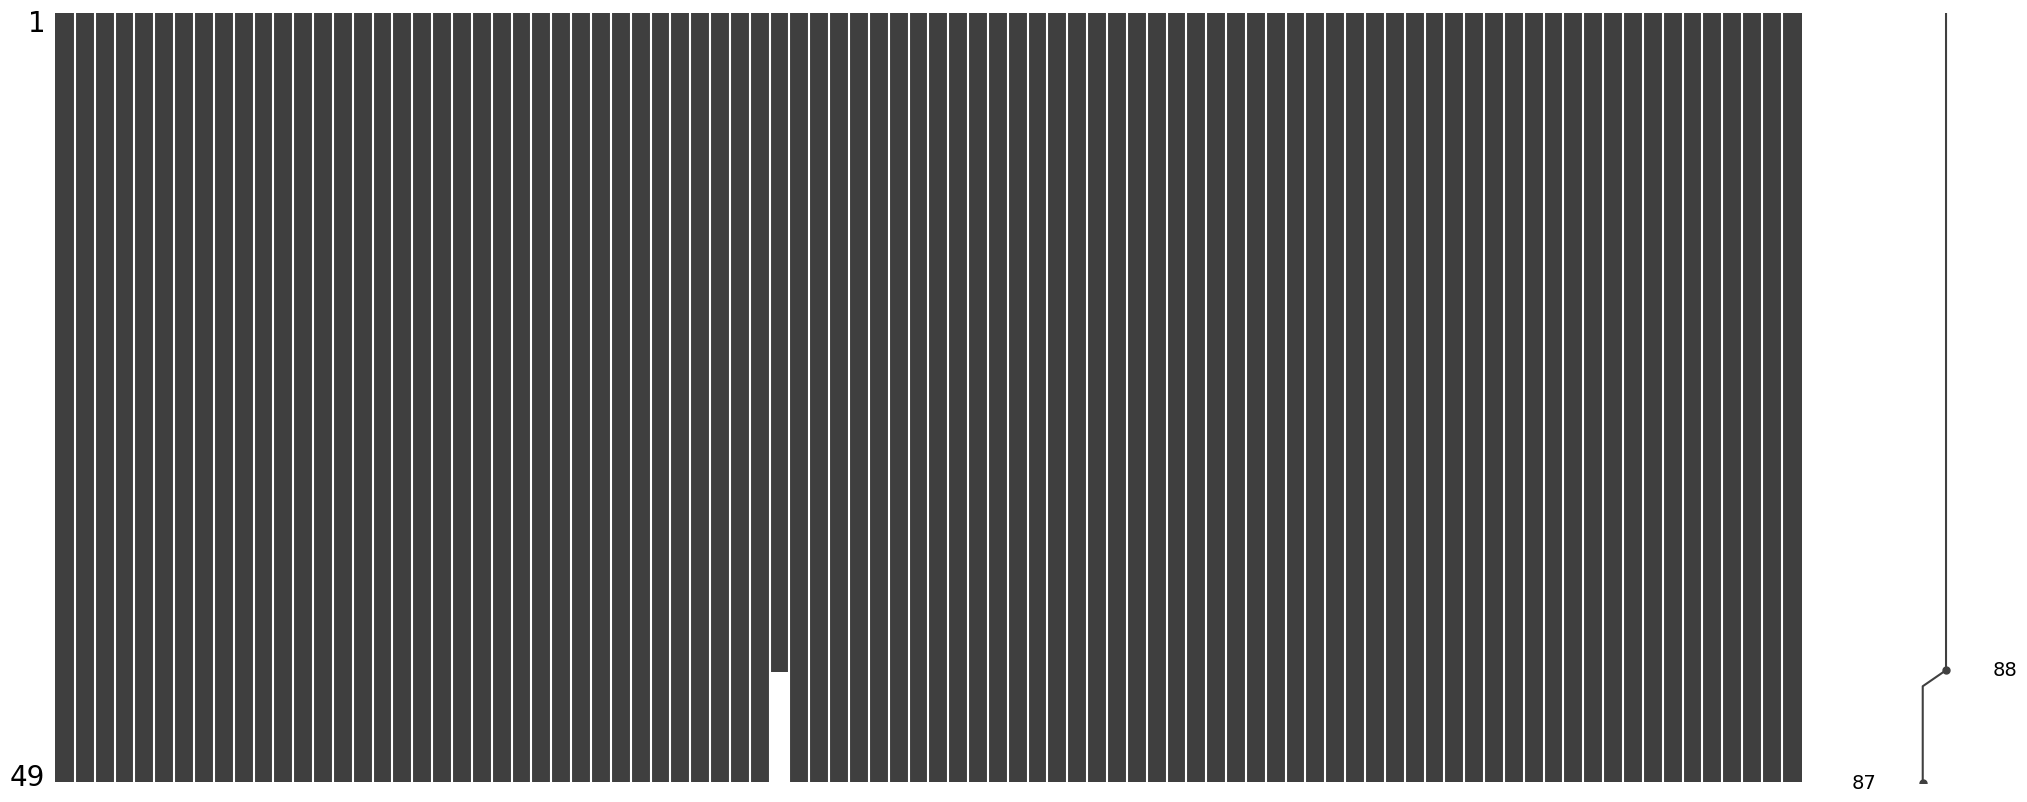

In [94]:
missingno.matrix(merged)

In [95]:
years = merged.year.unique()
years

array([2024], dtype=int64)

In [96]:
nuts3_units = merged.NUTS3_NAME.unique()
nuts3_units

array(['βορειος τομεας αθηνων', 'δυτικος τομεας αθηνων',
       'κεντρικος τομεας αθηνων', 'νοτιος τομεας αθηνων',
       'ανατολικη αττικη', 'δυτικη αττικη', 'πειραιας, νησοι'],
      dtype=object)

In [97]:
rows = []
for year in years:
    for region in nuts3_units:
        filtered_df = merged.loc[(merged['year'] == year) & (merged['NUTS3_NAME'] == region)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        tmin = robjects.IntVector(filtered_df['monthly_lst_min'].tolist())
        tmax = robjects.IntVector(filtered_df['monthly_lst_max'].tolist())
        prec = robjects.IntVector(filtered_df['monthly_acc_prec'].tolist())

        bio_vars = list(dismo.biovars(prec, tmin, tmax))

        rows.append({'NUTS3_NAME': region, 
                     'year': year, 
                     'bio1': bio_vars[0],
                     'bio2': bio_vars[1],
                     'bio3': bio_vars[2],
                     'bio4': bio_vars[3],
                     'bio5': bio_vars[4],
                     'bio6': bio_vars[5],
                     'bio7': bio_vars[6],
                     'bio8': bio_vars[7],
                     'bio9': bio_vars[8],
                     'bio10': bio_vars[9],
                     'bio11': bio_vars[10],
                     'bio12': bio_vars[11],
                     'bio13': bio_vars[12],
                     'bio14': bio_vars[13],
                     'bio15': bio_vars[14],
                     'bio16': bio_vars[15],
                     'bio17': bio_vars[16],
                     'bio18': bio_vars[17],
                     'bio19': bio_vars[18]})
        
biovars_df = pd.DataFrame(rows)

In [98]:
biovars_df.head(20)

,NUTS3_NAME,year,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,βορειος τομεας αθηνων,2024,19.857143,18.857143,48.351648,921.825311,41.000000,2.000000,39.000000,11.500000,23.833333,28.666667,11.500000,611.000000,171.000000,0.000000,76.570792,420.000000,121.000000,129.000000,420.000000
1,δυτικος τομεας αθηνων,2024,21.357143,19.285714,45.918367,1014.771849,43.000000,1.000000,42.000000,11.833333,25.333333,31.000000,11.833333,639.000000,178.000000,0.000000,77.332582,435.000000,107.000000,137.000000,435.000000
2,κεντρικος τομεας αθηνων,2024,20.785714,18.142857,45.357143,947.301933,42.000000,2.000000,40.000000,12.000000,24.666667,29.833333,12.000000,573.000000,172.000000,0.000000,81.234773,406.000000,97.000000,118.000000,406.000000
3,νοτιος τομεας αθηνων,2024,20.500000,17.285714,43.214286,934.523051,41.000000,1.000000,40.000000,11.500000,24.166667,29.000000,11.500000,534.000000,158.000000,0.000000,82.579200,390.000000,91.000000,101.000000,390.000000
4,ανατολικη αττικη,2024,19.571429,19.428571,49.816850,897.881104,40.000000,1.000000,39.000000,11.166667,27.833333,27.833333,11.166667,512.000000,141.000000,0.000000,78.360682,369.000000,98.000000,98.000000,369.000000
5,δυτικη αττικη,2024,18.928571,20.142857,50.357143,947.113409,40.000000,0.000000,40.000000,10.333333,23.000000,27.666667,10.333333,636.000000,195.000000,0.000000,87.515816,457.000000,85.000000,134.000000,457.000000
6,"πειραιας, νησοι",2024,19.285714,16.285714,47.899160,827.071713,38.000000,4.000000,34.000000,12.000000,27.166667,27.166667,12.000000,495.000000,209.000000,0.000000,105.834462,421.000000,44.000000,44.000000,421.000000


In [99]:
merged = pd.merge(merged, biovars_df,  how='left', on=['NUTS3_NAME', 'year'])

In [100]:
##check if biovars have the same value across all months
merged.loc[(merged['year'] == 2024) & (merged['NUTS3_NAME'] == 'βορειος τομεας αθηνων')]

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2024-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.825080,38.055971,1,2024,0.249087,0.123696,-0.231308,-0.123696,0.246233,0.158698,-0.226363,-0.158698,0.039974,0.028491,0.031608,0.028491,11.833484,7.042301,9.437892,11.833484,15.167149,18.239548,26.853778,7.042301,8.088161,9.059548,14.650667,9.437892,11.627655,13.649548,20.752222,3.913518,29.682600,50.063076,117.341162,121.319052,5376.666667,173.440860,12596.173352,1653.260278,7.066667,199.653520,293.515429,186.164165,0.000000,11.320098,6975.099311,9.886334,2,158.038271,190.198124,179.915914,0.000000,1.000000,15103.584543,3887.958042,14,242.913089,460.563721,193.437501,0.000000,79.730978,2296.456415,1184.432609,4.682287,23.874457,92.528119,3.668097,0.000000,21.863192,22,9,20,13,13,10,8,9,2,2.624667,16.636667,121.319052,0,19.857143,18.857143,48.351648,921.825311,41.000000,2.000000,39.000000,11.500000,23.833333,28.666667,11.500000,611.000000,171.000000,0.000000,76.570792,420.000000,121.000000,129.000000,420.000000
7,2024-02,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.825080,38.055971,2,2024,0.228169,0.101152,-0.222536,-0.101152,0.209502,0.150995,-0.189110,-0.150995,0.034636,0.025634,0.029816,0.025634,15.167149,8.088161,11.627655,11.833484,15.167149,18.239548,26.853778,7.042301,8.088161,9.059548,14.650667,9.437892,11.627655,13.649548,20.752222,4.441161,87.894409,102.998886,128.797071,250.112727,6009.866667,207.236782,12596.173352,1653.260278,7.066667,199.653520,293.515429,186.164165,0.000000,11.320098,6975.099311,9.886334,2,158.038271,190.198124,179.915914,0.000000,1.000000,15103.584543,3887.958042,14,242.913089,460.563721,193.437501,0.000000,79.730978,2296.456415,1184.432609,4.682287,23.874457,92.528119,3.668097,0.000000,21.863192,22,9,20,13,13,10,8,9,2,2.243333,18.363333,128.793675,0,19.857143,18.857143,48.351648,921.825311,41.000000,2.000000,39.000000,11.500000,23.833333,28.666667,11.500000,611.000000,171.000000,0.000000,76.570792,420.000000,121.000000,129.000000,420.000000
14,2024-03,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.825080,38.055971,3,2024,0.226509,0.068302,-0.222222,-0.068302,0.228855,0.097824,-0.208891,-0.097824,0.031925,0.023888,0.033052,0.023888,18.239548,9.059548,13.649548,11.833484,15.167149,18.239548,26.853778,7.042301,8.088161,9.059548,14.650667,9.437892,11.627655,13.649548,20.752222,5.541233,8.489855,25.397115,68.898215,421.890949,3649.466667,117.724731,12596.173352,1653.260278,7.066667,199.653520,293.515429,186.164165,0.000000,11.320098,6975.099311,9.886334,2,158.038271,190.198124,179.915914,0.000000,1.000000,15103.584543,3887.958042,14,242.913089,460.563721,193.437501,0.000000,79.730978,2296.456415,1184.

In [101]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Demographics_Processed.csv', encoding = enc)

In [102]:
df_demographics

,NUTS3_CODE,YEAR,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1711,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1712,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1713,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000
1714,EL653,2022,14396.000000,72340.000000,29251.000000,115987.000000,13728.000000,67675.000000,32412.000000,113815.000000


In [103]:
df_demographics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [104]:
df_demographics

,NUTS3_ID,year,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1711,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1712,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1713,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000
1714,EL653,2022,14396.000000,72340.000000,29251.000000,115987.000000,13728.000000,67675.000000,32412.000000,113815.000000


In [105]:
dataset = pd.merge(merged, df_demographics,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

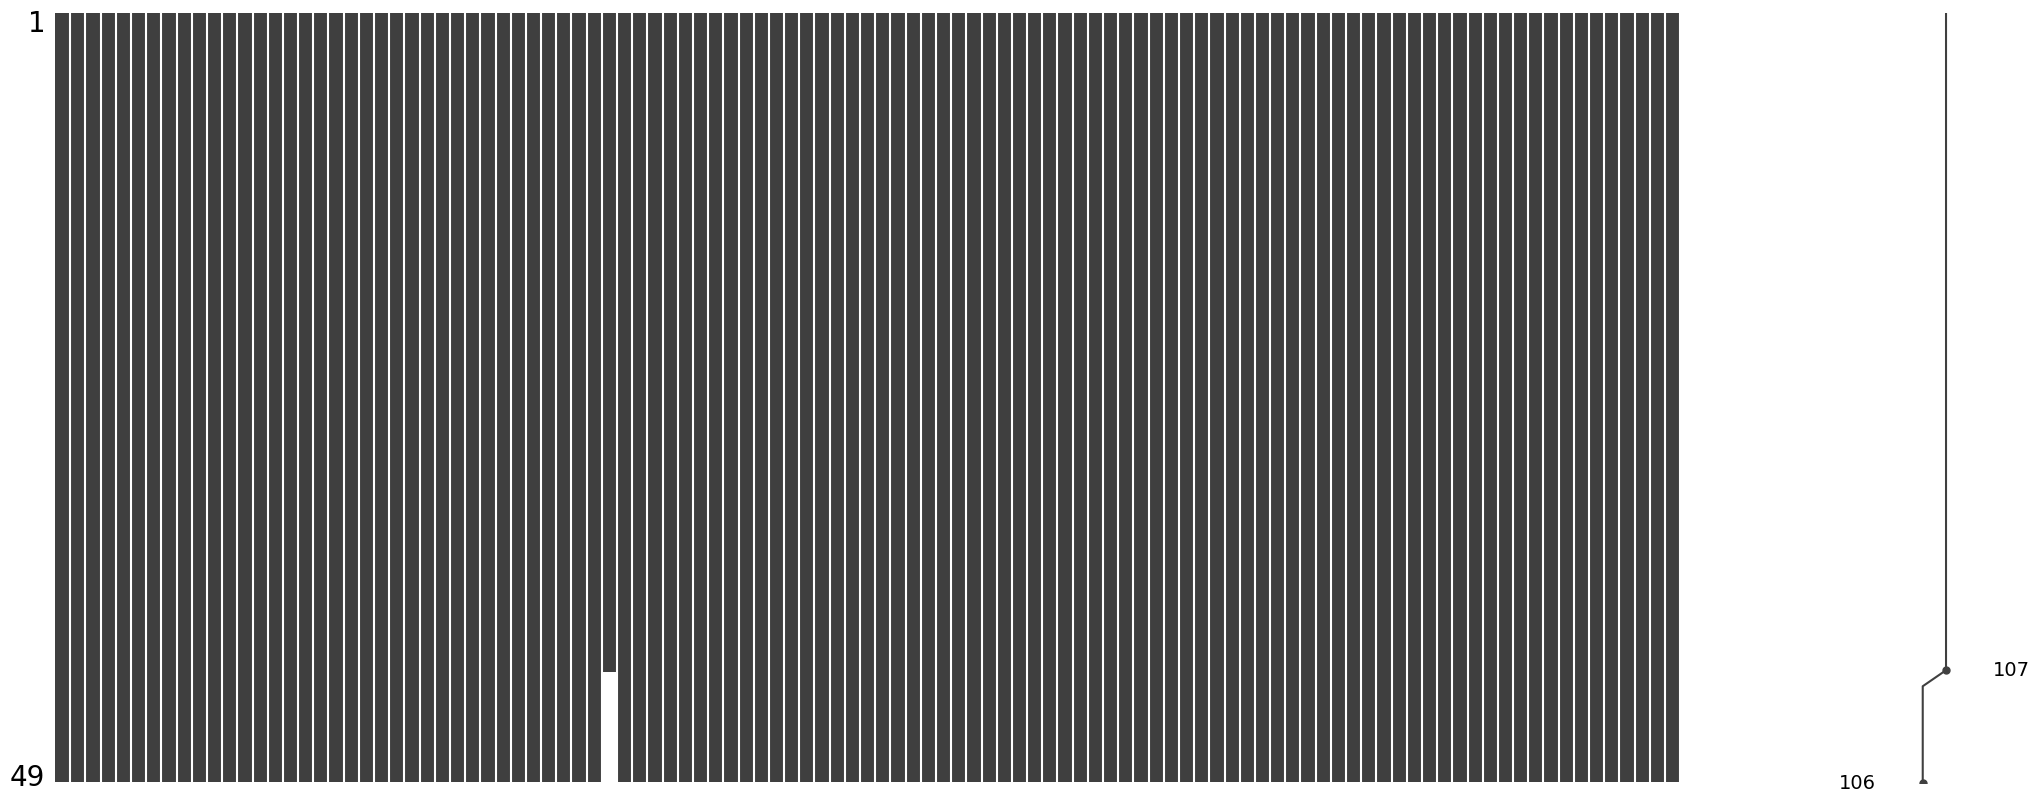

In [106]:
missingno.matrix(dataset)

In [107]:
df_economics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Economics_Processed.csv', encoding = enc)

In [108]:
df_economics

,NUTS3_CODE,YEAR,MIO_EUR
0,EL301,2000,10002.340000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1139,EL653,2017,3112.330000
1140,EL653,2018,3111.760000
1141,EL653,2019,3149.580000
1142,EL653,2020,2795.860000


In [109]:
df_economics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [110]:
df_economics

,NUTS3_ID,year,MIO_EUR
0,EL301,2000,10002.340000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1139,EL653,2017,3112.330000
1140,EL653,2018,3111.760000
1141,EL653,2019,3149.580000
1142,EL653,2020,2795.860000


In [111]:
dataset = pd.merge(dataset, df_economics,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

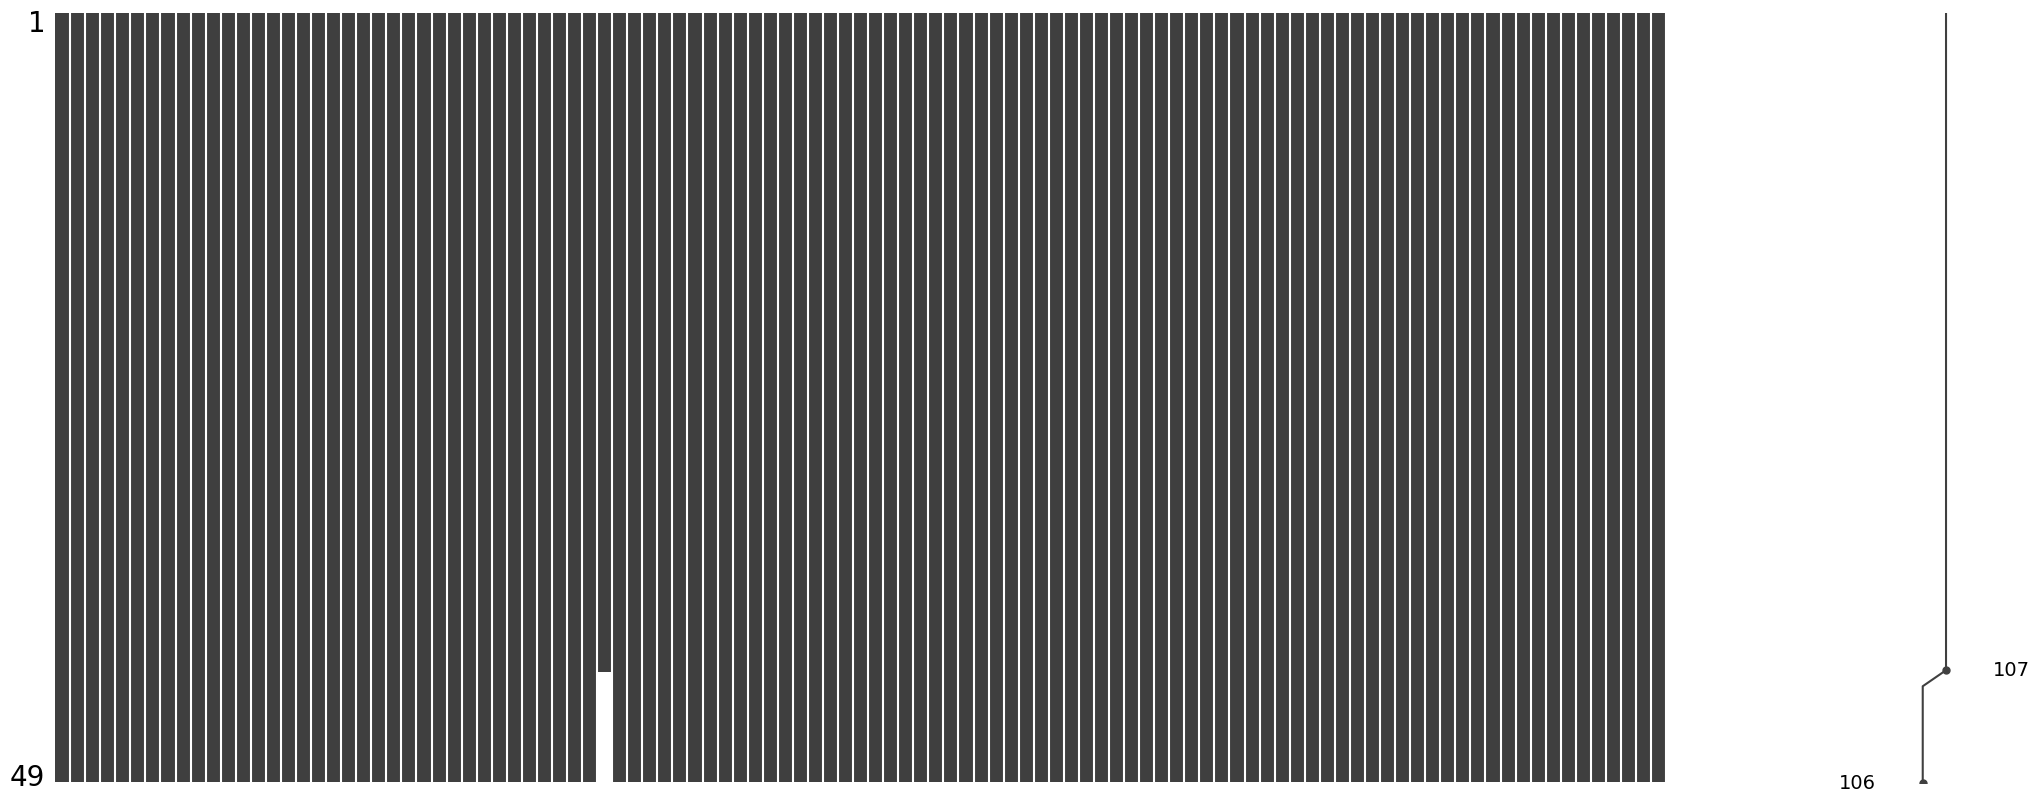

In [112]:
missingno.matrix(dataset)

In [113]:
df_trade = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Trade_Processed.csv', encoding = enc)

In [114]:
df_trade

,NUTS3_CODE,YEAR,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
766,EL653,2018,2358.000000,2885.000000
767,EL653,2019,2914.000000,3549.000000
768,EL653,2020,4572.000000,4962.000000
769,EL653,2021,3040.000000,3666.000000


In [115]:
df_trade.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [116]:
df_trade

,NUTS3_ID,year,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
766,EL653,2018,2358.000000,2885.000000
767,EL653,2019,2914.000000,3549.000000
768,EL653,2020,4572.000000,4962.000000
769,EL653,2021,3040.000000,3666.000000


In [117]:
dataset = pd.merge(dataset, df_trade,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

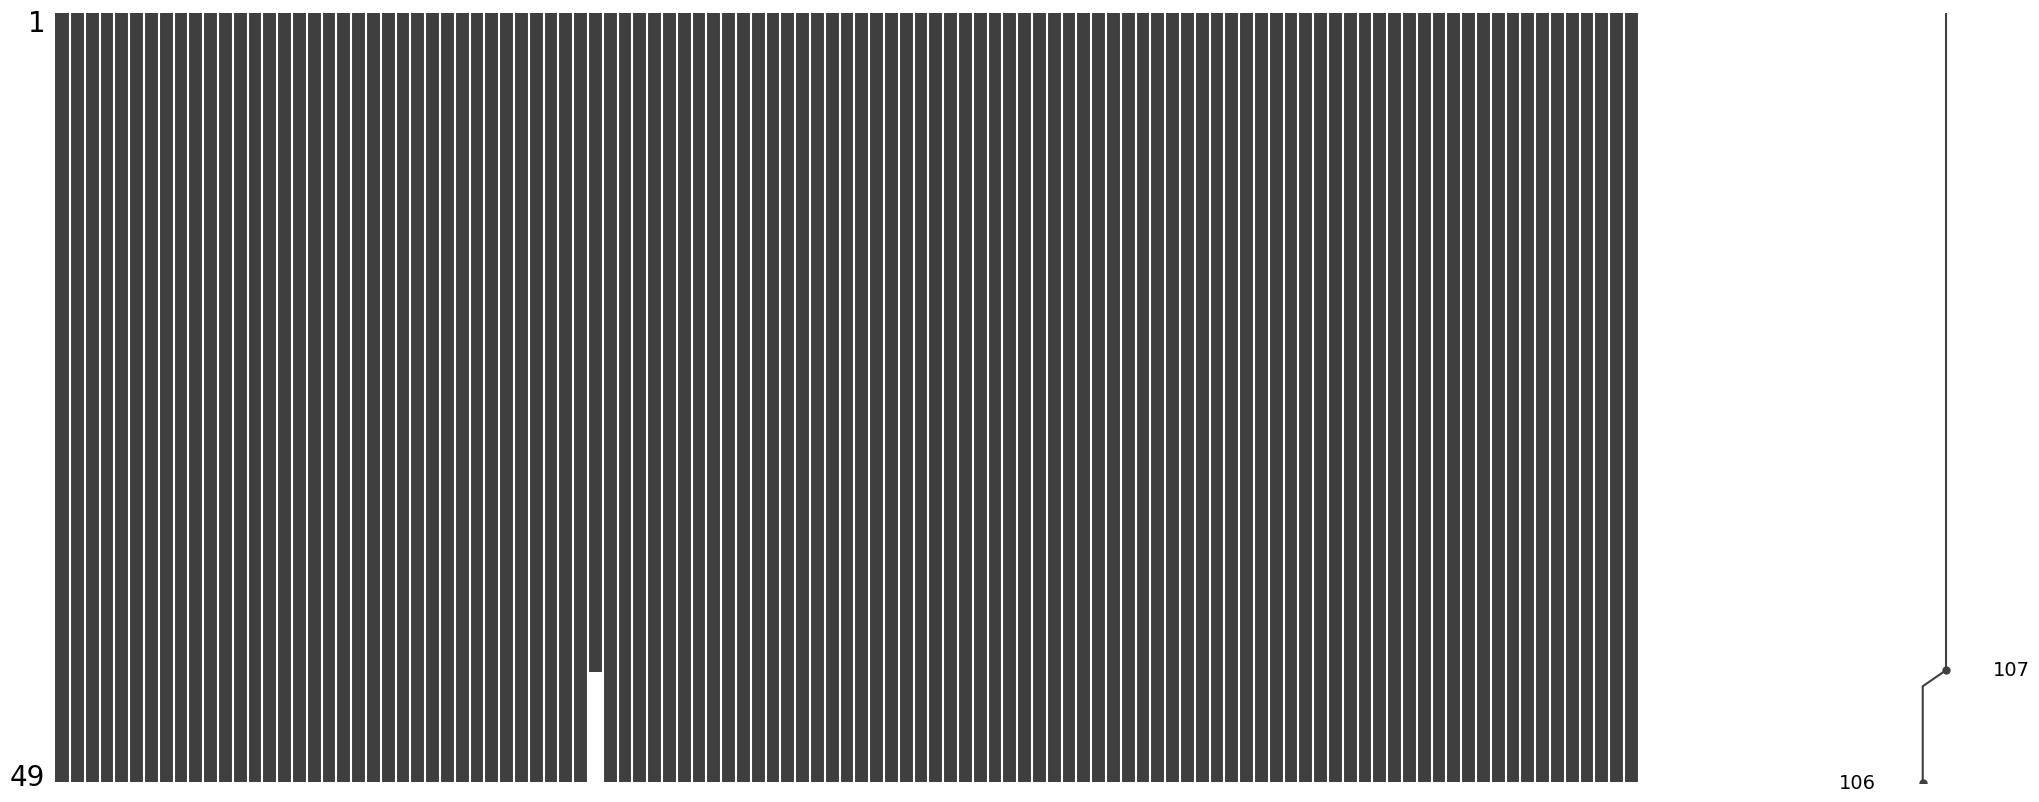

In [118]:
missingno.matrix(dataset)

In [119]:
missing = describe_dataframe(dataset)

In [120]:
missing

,Column,Missing
0,dt_placement,0.000000
1,NUTS2_ID,0.000000
2,NUTS2_NAME,0.000000
3,NUTS3_ID,0.000000
4,NUTS3_NAME,0.000000
...,...,...
113,F_Y_GE65,100.000000
114,F_TOTAL,100.000000
115,MIO_EUR,100.000000
116,L_TOTAL,100.000000


In [121]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2024-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.825080,38.055971,1,2024,0.249087,0.123696,-0.231308,-0.123696,0.246233,0.158698,-0.226363,-0.158698,0.039974,0.028491,0.031608,0.028491,11.833484,7.042301,9.437892,11.833484,15.167149,18.239548,26.853778,7.042301,8.088161,9.059548,14.650667,9.437892,11.627655,13.649548,20.752222,3.913518,29.682600,50.063076,117.341162,121.319052,5376.666667,173.440860,12596.173352,1653.260278,7.066667,199.653520,293.515429,186.164165,0.000000,11.320098,6975.099311,9.886334,2,158.038271,190.198124,179.915914,0.000000,1.000000,15103.584543,3887.958042,14,242.913089,460.563721,193.437501,0.000000,79.730978,2296.456415,1184.432609,4.682287,23.874457,92.528119,3.668097,0.000000,21.863192,22,9,20,13,13,10,8,9,2,2.624667,16.636667,121.319052,0,19.857143,18.857143,48.351648,921.825311,41.000000,2.000000,39.000000,11.500000,23.833333,28.666667,11.500000,611.000000,171.000000,0.000000,76.570792,420.000000,121.000000,129.000000,420.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.686502,38.024894,1,2024,0.102331,0.022448,-0.126808,-0.022448,0.125197,0.047598,-0.137139,-0.047598,0.058575,0.030247,0.040470,0.030247,13.915032,7.783935,10.849484,13.915032,16.596483,19.168194,28.569200,7.783935,9.503655,10.866774,16.326000,10.849484,13.050069,15.017484,22.447600,3.474230,29.121529,46.517285,104.891998,107.701138,12014.400000,387.561290,7495.493496,2041.783345,2.800000,135.961772,107.413199,175.185410,0.000000,5.799639,5369.544043,863.918625,1,124.980862,72.025314,168.746576,0.000000,2.741869,9092.468792,3043.444411,5,157.020761,152.212002,180.041979,0.000000,9.259888,1549.348962,1081.112134,1.788854,12.696343,30.830096,4.405654,0.000000,2.978368,1,9,1,13,13,10,8,9,2,1.650000,17.514000,107.701138,0,21.357143,19.285714,45.918367,1014.771849,43.000000,1.000000,42.000000,11.833333,25.333333,31.000000,11.833333,639.000000,178.000000,0.000000,77.332582,435.000000,107.000000,137.000000,435.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.757527,37.973503,1,2024,0.167139,0.079421,-0.136629,-0.079421,0.183724,0.093767,-0.149276,-0.093767,0.081446,0.049275,0.073039,0.049275,12.635161,7.748065,10.191613,12.635161,15.306069,18.595613,27.249400,7.748065,9.145862,10.398774,15.664000,10.191613,12.225966,14.497194,21.456700,3.144156,18.877301,28.153147,94.893039,97.468831,10429.200000,336.425806,7451.460209,1907.131239,7.200000,218.497003,207.330391,190.939862,0.00000

In [122]:
dataset.reset_index(inplace=True, drop=True)

In [123]:
dataset['cases'].value_counts()

cases
0    49
Name: count, dtype: int64

In [124]:
dataset['cases'].sum()

0

In [125]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2024-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.825080,38.055971,1,2024,0.249087,0.123696,-0.231308,-0.123696,0.246233,0.158698,-0.226363,-0.158698,0.039974,0.028491,0.031608,0.028491,11.833484,7.042301,9.437892,11.833484,15.167149,18.239548,26.853778,7.042301,8.088161,9.059548,14.650667,9.437892,11.627655,13.649548,20.752222,3.913518,29.682600,50.063076,117.341162,121.319052,5376.666667,173.440860,12596.173352,1653.260278,7.066667,199.653520,293.515429,186.164165,0.000000,11.320098,6975.099311,9.886334,2,158.038271,190.198124,179.915914,0.000000,1.000000,15103.584543,3887.958042,14,242.913089,460.563721,193.437501,0.000000,79.730978,2296.456415,1184.432609,4.682287,23.874457,92.528119,3.668097,0.000000,21.863192,22,9,20,13,13,10,8,9,2,2.624667,16.636667,121.319052,0,19.857143,18.857143,48.351648,921.825311,41.000000,2.000000,39.000000,11.500000,23.833333,28.666667,11.500000,611.000000,171.000000,0.000000,76.570792,420.000000,121.000000,129.000000,420.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.686502,38.024894,1,2024,0.102331,0.022448,-0.126808,-0.022448,0.125197,0.047598,-0.137139,-0.047598,0.058575,0.030247,0.040470,0.030247,13.915032,7.783935,10.849484,13.915032,16.596483,19.168194,28.569200,7.783935,9.503655,10.866774,16.326000,10.849484,13.050069,15.017484,22.447600,3.474230,29.121529,46.517285,104.891998,107.701138,12014.400000,387.561290,7495.493496,2041.783345,2.800000,135.961772,107.413199,175.185410,0.000000,5.799639,5369.544043,863.918625,1,124.980862,72.025314,168.746576,0.000000,2.741869,9092.468792,3043.444411,5,157.020761,152.212002,180.041979,0.000000,9.259888,1549.348962,1081.112134,1.788854,12.696343,30.830096,4.405654,0.000000,2.978368,1,9,1,13,13,10,8,9,2,1.650000,17.514000,107.701138,0,21.357143,19.285714,45.918367,1014.771849,43.000000,1.000000,42.000000,11.833333,25.333333,31.000000,11.833333,639.000000,178.000000,0.000000,77.332582,435.000000,107.000000,137.000000,435.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.757527,37.973503,1,2024,0.167139,0.079421,-0.136629,-0.079421,0.183724,0.093767,-0.149276,-0.093767,0.081446,0.049275,0.073039,0.049275,12.635161,7.748065,10.191613,12.635161,15.306069,18.595613,27.249400,7.748065,9.145862,10.398774,15.664000,10.191613,12.225966,14.497194,21.456700,3.144156,18.877301,28.153147,94.893039,97.468831,10429.200000,336.425806,7451.460209,1907.131239,7.200000,218.497003,207.330391,190.939862,0.00000

In [126]:
cols = dataset.columns

In [127]:
print(cols)


Index(['dt_placement', 'NUTS2_ID', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x',
       'y', 'month', 'year', 'ndvi',
       ...
       'M_Y15-64', 'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65',
       'F_TOTAL', 'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL'],
      dtype='object', length=118)


In [128]:
len(cols)

118

In [129]:
dataset.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2024.csv", encoding = enc, index = False)
